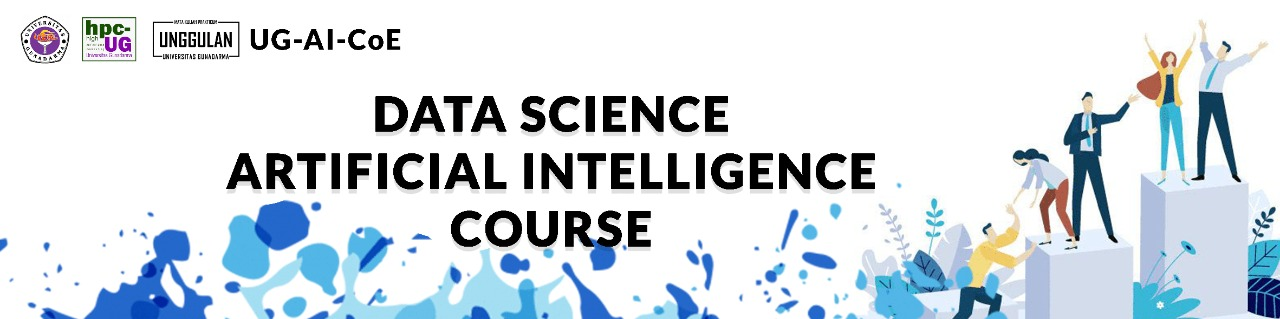

File ini merupakan hasil pengerjaan *final project* peserta yang dilakukan dalam kegiatan Kursus Data Science Universitas Gunadarma Periode 02 Juni - 13 Juni 2026 (Semester 8) untuk Skema Ilmuwan Data Madya (*Associate Data Scientist*).

---

# **(Prediksi Customer Churn pada Perusahaan Telekomunikasi Menggunakan Random Forest)**

Disusun Oleh: <br>
  * Nama Mahasiswa: Athorid Bagas Raditya Hadidharma <br>
  * NPM: 50422291 <br>
  * Kelas Kursus/Kelompok Kursus: Kelas 2/Kelompok B<br><br>

---

<a id="daftar-isi"></a>

## Daftar Isi

Klik untuk melompat ke unit yang dituju:

1. [UNIT #1 - Mengumpulkan Data &nbsp; J.62DMI00.004.1](#unit1)
2. [UNIT #2 - Menelaah Data &nbsp; J.62DMI00.005.1](#unit2)
3. [UNIT #3 - Memvalidasi Data &nbsp; J.62DMI00.006.1](#unit3)
4. [UNIT #4 - Menentukan Objek Data &nbsp; J.62DMI00.007.1](#unit4)
5. [UNIT #5 - Membersihkan Data &nbsp; J.62DMI00.008.1](#unit5)
6. [UNIT #6 - Mengkonstruksi Data &nbsp; J.62DMI00.009.1](#unit6)
7. [UNIT #7 - Menentukan Label Data &nbsp; J.62DMI00.010.1](#unit7)
8. [UNIT #8 - Membangun Model &nbsp; J.62DMI00.013.1](#unit8)
9. [UNIT #9 - Mengevaluasi Hasil Pemodelan &nbsp; J.62DMI00.014.1](#unit9)

<a id="unit1"></a>

# UNIT #1 - Mengumpulkan Data
### Kode Unit: J.62DMI00.004.1

[⬆ Kembali ke Daftar Isi](#daftar-isi)

---

## 1. Menentukan Kebutuhan Data

### 1.1 Kebutuhan Data Diidentifikasi Sesuai Tujuan Teknis Data Science (kode + deskriptif)

Tujuan project ini adalah membangun model klasifikasi untuk memprediksi customer churn pada perusahaan telekomunikasi.

Data yang dibutuhkan harus memuat informasi mengenai:

- Profil pelanggan
- Lama berlangganan
- Jenis layanan yang digunakan
- Metode pembayaran
- Biaya layanan
- Status churn pelanggan

Variabel target yang digunakan adalah:

| Kolom | Keterangan |
|---------|-----------|
| Churn | Status pelanggan (Yes/No) |

**Catatan Pembelajaran:**  
Cell ini memasang library yang dibutuhkan notebook. Jika library sudah tersedia, output biasanya menampilkan `Requirement already satisfied`. Cell ini boleh dijalankan saat `Run All`, tetapi membutuhkan koneksi internet jika ada library yang belum terpasang.

In [1]:
# Install library yang dibutuhkan jika belum tersedia di environment notebook
%pip install pandas numpy matplotlib seaborn scikit-learn


Note: you may need to restart the kernel to use updated packages.


**Catatan Pembelajaran:**  
Cell ini menyiapkan library utama dan membuat tabel kebutuhan data. Bagian `import` memanggil alat analisis, sedangkan `kebutuhan_data` menjelaskan data apa saja yang diperlukan untuk menjawab masalah churn.

In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from pathlib import Path

pd.set_option("display.max_columns", 100)
sns.set_theme(style="whitegrid")

kebutuhan_data = pd.DataFrame({
    "Kategori Data": [
        "Profil pelanggan",
        "Lama berlangganan",
        "Jenis layanan",
        "Kontrak dan pembayaran",
        "Biaya layanan",
        "Target label"
    ],
    "Contoh Kolom": [
        "gender, SeniorCitizen, Partner, Dependents",
        "tenure",
        "PhoneService, InternetService, OnlineSecurity, TechSupport",
        "Contract, PaperlessBilling, PaymentMethod",
        "MonthlyCharges, TotalCharges",
        "Churn"
    ],
    "Peran dalam Project": [
        "Menggambarkan karakteristik dasar pelanggan",
        "Mengukur durasi hubungan pelanggan dengan perusahaan",
        "Menjelaskan layanan yang digunakan pelanggan",
        "Menjelaskan pola kontrak dan pembayaran pelanggan",
        "Menggambarkan nilai finansial pelanggan",
        "Menjadi variabel yang diprediksi oleh model klasifikasi"
    ]
})

kebutuhan_data

,Kategori Data,Contoh Kolom,Peran dalam Project
0,Profil pelanggan,"gender, SeniorCitizen, Partner, Dependents",Menggambarkan karakteristik dasar pelanggan
1,Lama berlangganan,tenure,Mengukur durasi hubungan pelanggan dengan peru...
2,Jenis layanan,"PhoneService, InternetService, OnlineSecurity,...",Menjelaskan layanan yang digunakan pelanggan
3,Kontrak dan pembayaran,"Contract, PaperlessBilling, PaymentMethod",Menjelaskan pola kontrak dan pembayaran pelanggan
4,Biaya layanan,"MonthlyCharges, TotalCharges",Menggambarkan nilai finansial pelanggan
5,Target label,Churn,Menjadi variabel yang diprediksi oleh model kl...


**Interpretasi Output:**  
Tabel di atas menunjukkan kebutuhan data yang relevan dengan tujuan teknis data science. Setiap kategori data memiliki peran untuk membantu model mengenali pola pelanggan yang berisiko churn.

**Kesimpulan:**  
Kebutuhan data telah sesuai karena dataset memuat fitur pelanggan, layanan, kontrak, biaya, dan target `Churn`.

---

### 1.2 Kebutuhan Data Diperiksa Ketersediaannya Sesuai Aturan yang Berlaku (deskriptif + kode)

Dataset diperoleh dari Kaggle dan bersifat publik sehingga dapat digunakan untuk kebutuhan pembelajaran dan penelitian.

Sumber Dataset:

https://www.kaggle.com/datasets/blastchar/telco-customer-churn

File dataset sudah diunduh secara lokal dan dinamai ulang menjadi:

`Telco-Customer-Churn.csv`

**Catatan Pembelajaran:**  
Cell ini menentukan nama file dataset lokal dan memeriksa apakah file tersedia di folder utama atau folder `data`. Tujuannya memastikan notebook tidak lanjut ke proses analisis sebelum dataset benar-benar ada.

In [3]:
FILE_NAME = "Telco-Customer-Churn.csv"

candidate_paths = [
    Path(FILE_NAME),
    Path("data") / FILE_NAME
]

available_paths = [path for path in candidate_paths if path.exists()]

for path in candidate_paths:
    status = "tersedia" if path.exists() else "belum tersedia"
    print(f"{path}: {status}")

Telco-Customer-Churn.csv: tersedia
data/Telco-Customer-Churn.csv: belum tersedia


**Interpretasi Output:**  
Jika output menunjukkan file `Telco-Customer-Churn.csv` tersedia, maka dataset sudah siap dibaca menggunakan Pandas. Jika belum tersedia, file perlu diletakkan di folder kerja utama atau folder `data`.

**Kesimpulan:**  
Ketersediaan data diperiksa berdasarkan keberadaan file lokal yang akan digunakan dalam notebook.

---

### 1.3 Kebutuhan Data Ditentukan Volumenya Sesuai Tujuan Teknis Data Science (kode)

Dataset memiliki ukuran yang dapat diperiksa menggunakan `df.shape`.

**Catatan Pembelajaran:**  
Cell ini membaca dataset CSV menjadi DataFrame Pandas bernama `df`, lalu menampilkan ukurannya dengan `df.shape`. Output `(7043, 21)` berarti ada 7043 baris pelanggan dan 21 kolom atribut.

In [4]:
if not available_paths:
    raise FileNotFoundError(
        f"File '{FILE_NAME}' belum ditemukan. Simpan file di folder kerja utama atau folder 'data/'."
    )

data_path = available_paths[0]
df = pd.read_csv(data_path)

df.shape

(7043, 21)

Output yang diharapkan:

```text
(7043, 21)
```

Keterangan:

- Jumlah baris : 7.043
- Jumlah kolom : 21
- Target klasifikasi : Churn

Volume data dinilai cukup untuk membangun model machine learning klasifikasi.

**Kesimpulan:**  
Volume dataset sesuai dengan kebutuhan teknis karena memiliki ribuan data pelanggan dan 21 atribut yang dapat digunakan dalam analisis churn.

---

## 2. Mengambil Data

### 2.1 Metode dan Tools Pengambilan Data Diidentifikasi (deskriptif)

Metode pengambilan data dilakukan melalui pengunduhan dataset publik dari Kaggle.

Tools yang digunakan:

- Kaggle
- JupyterLab atau Jupyter Notebook
- Python
- Pandas

**Kesimpulan:**  
Metode pengambilan data sesuai dengan tujuan teknis karena dataset tersedia dalam format CSV dan mudah dibaca menggunakan Pandas.

---

### 2.2 Tools Pengambilan Data Ditentukan (deskriptif)

Library yang digunakan:

- pandas
- numpy
- matplotlib
- seaborn

Untuk Unit #1, library utama yang digunakan adalah `pandas` karena data berbentuk tabular CSV.

**Kesimpulan:**  
Tools yang dipilih sudah sesuai untuk membaca data, memeriksa struktur data, dan melakukan eksplorasi awal.

---

### 2.3 Tools Pengambilan Data Disiapkan Sesuai Tujuan Teknis Data Science (kode)

Persiapan tools dilakukan dengan mengimpor library, menentukan nama file, dan menentukan lokasi dataset.

**Catatan Pembelajaran:**  
Cell ini membuat tabel ringkasan tools yang digunakan. Ini berguna untuk menjelaskan kepada penguji bahwa proses pengambilan data dilakukan dengan alat yang sesuai, seperti Kaggle, Python, dan Pandas.

In [5]:
tools_pengambilan_data = pd.DataFrame({
    "Tools": ["Kaggle", "Jupyter Notebook", "Python", "Pandas"],
    "Fungsi": [
        "Sumber dataset",
        "Lingkungan kerja analisis",
        "Bahasa pemrograman data science",
        "Membaca dan mengelola data CSV"
    ]
})

tools_pengambilan_data

,Tools,Fungsi
0,Kaggle,Sumber dataset
1,Jupyter Notebook,Lingkungan kerja analisis
2,Python,Bahasa pemrograman data science
3,Pandas,Membaca dan mengelola data CSV


**Interpretasi Output:**  
Tabel menunjukkan tools yang digunakan beserta fungsinya dalam proses pengambilan data.

**Kesimpulan:**  
Tools telah disiapkan dan sesuai dengan kebutuhan teknis proyek data science.

---

### 2.4 Proses Pengambilan Data Dijalankan Sesuai Tools yang Telah Disiapkan (kode)

Proses pengambilan data dijalankan dengan membaca file CSV lokal menggunakan `pd.read_csv()`.

**Catatan Pembelajaran:**  
Cell ini menampilkan lima baris pertama dataset setelah berhasil dibaca. Tujuannya adalah validasi cepat bahwa struktur kolom dan isi data sudah tampil dengan benar.

In [6]:
df = pd.read_csv(data_path)
df.head()

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,Yes,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,No,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,Yes,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,No,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,No,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


**Interpretasi Output:**  
Output menampilkan lima baris pertama dataset. Jika data tampil dalam bentuk tabel, maka proses pengambilan data berhasil dilakukan.

**Kesimpulan:**  
Data berhasil diambil dan dapat digunakan pada tahap analisis berikutnya.

---

## 3. Mengintegrasikan Data

### 3.1 Integritas Data Diperiksa Sesuai Tujuan Teknis Data Science (kode)

Integritas data diperiksa untuk memastikan data memiliki struktur yang konsisten, kolom target tersedia, tidak ada duplikasi baris, dan kolom utama dapat digunakan untuk analisis churn.

**Catatan Pembelajaran:**  
Cell ini memeriksa integritas awal dataset, seperti keberadaan target `Churn`, keunikan `customerID`, duplikasi, dan kesesuaian jumlah baris/kolom. Ini membuktikan data layak dilanjutkan ke tahap telaah.

In [7]:
integrity_check = pd.DataFrame({
    "Pemeriksaan": [
        "Kolom target Churn tersedia",
        "customerID unik",
        "Tidak ada baris duplikat",
        "Jumlah kolom sesuai referensi",
        "Jumlah baris sesuai referensi"
    ],
    "Hasil": [
        "Churn" in df.columns,
        df["customerID"].is_unique if "customerID" in df.columns else False,
        df.duplicated().sum() == 0,
        df.shape[1] == 21,
        df.shape[0] == 7043
    ]
})

integrity_check

,Pemeriksaan,Hasil
0,Kolom target Churn tersedia,True
1,customerID unik,True
2,Tidak ada baris duplikat,True
3,Jumlah kolom sesuai referensi,True
4,Jumlah baris sesuai referensi,True


**Interpretasi Output:**  
Jika seluruh nilai pada kolom `Hasil` bernilai `True`, maka integritas awal dataset sudah baik untuk digunakan pada tahap telaah data.

**Kesimpulan:**  
Integritas data diperiksa melalui keberadaan target, keunikan ID pelanggan, duplikasi, dan kesesuaian volume data.

---

### 3.2 Data Diintegrasikan Sesuai Tujuan Teknis Data Science (deskriptif + kode)

Dataset IBM Telco Customer Churn tersedia sebagai satu file CSV, sehingga tidak diperlukan proses penggabungan beberapa tabel. Integrasi data dilakukan dengan memastikan seluruh kolom dalam satu DataFrame `df` dapat digunakan sebagai sumber data utama untuk analisis dan pemodelan.

**Catatan Pembelajaran:**  
Cell ini membuat salinan data bernama `df_integrated`. Karena dataset hanya berasal dari satu CSV, integrasi dilakukan dengan menjadikan satu DataFrame sebagai sumber utama analisis.

In [8]:
df_integrated = df.copy()

print("Ukuran data terintegrasi:", df_integrated.shape)
print("Kolom target tersedia:", "Churn" in df_integrated.columns)

df_integrated.head()

Ukuran data terintegrasi: (7043, 21)
Kolom target tersedia: True


,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,Yes,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,No,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,Yes,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,No,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,No,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


**Interpretasi Output:**  
DataFrame `df_integrated` menjadi data utama yang akan digunakan pada unit selanjutnya. Karena dataset berasal dari satu file, proses integrasi berfokus pada penyatuan data ke dalam satu objek DataFrame yang konsisten.

**Kesimpulan Unit #1:**  
Data telah dikumpulkan, diperiksa ketersediaannya, dibaca ke dalam notebook, dan diintegrasikan ke dalam DataFrame utama. Dataset siap digunakan untuk Unit #2, yaitu menelaah data.

<a id="unit2"></a>

# UNIT #2 - Menelaah Data
### Kode Unit: J.62DMI00.005.1

[⬆ Kembali ke Daftar Isi](#daftar-isi)

---

## 1. Menganalisis Tipe dan Relasi Data

### 1.1 Tipe Data yang Terkumpul Diidentifikasi Sesuai Tujuan Teknis (kode)

Pada tahap ini dilakukan identifikasi tipe data untuk mengetahui kolom numerik, kategorikal, dan target. Informasi ini penting karena model machine learning membutuhkan perlakuan berbeda untuk tipe data yang berbeda.

**Catatan Pembelajaran:**  
Cell ini merangkum tipe data, jumlah nilai unik, dan missing value setiap kolom. Informasi ini penting untuk menentukan kolom mana yang numerik, kategorikal, dan perlu dibersihkan.

In [9]:
tipe_data = pd.DataFrame({
    "Kolom": df_integrated.columns,
    "Tipe Data": df_integrated.dtypes.astype(str).values,
    "Jumlah Nilai Unik": df_integrated.nunique().values,
    "Jumlah Missing": df_integrated.isna().sum().values
})

tipe_data

,Kolom,Tipe Data,Jumlah Nilai Unik,Jumlah Missing
0,customerID,str,7043,0
1,gender,str,2,0
2,SeniorCitizen,int64,2,0
3,Partner,str,2,0
4,Dependents,str,2,0
5,tenure,int64,73,0
6,PhoneService,str,2,0
7,MultipleLines,str,3,0
8,InternetService,str,3,0
9,OnlineSecurity,str,3,0


**Catatan Pembelajaran:**  
Cell ini memisahkan fitur numerik dan kategorikal. Pemisahan ini penting karena fitur numerik dapat langsung dihitung, sedangkan fitur kategorikal perlu encoding sebelum dipakai model machine learning.

In [10]:
numeric_columns = df_integrated.select_dtypes(include=["number"]).columns.tolist()
categorical_columns = [
    column for column in df_integrated.columns
    if pd.api.types.is_object_dtype(df_integrated[column])
    or pd.api.types.is_string_dtype(df_integrated[column])
]

print("Kolom numerik:")
print(numeric_columns)

print("\nKolom kategorikal:")
print(categorical_columns)

Kolom numerik:
['SeniorCitizen', 'tenure', 'MonthlyCharges']

Kolom kategorikal:
['customerID', 'gender', 'Partner', 'Dependents', 'PhoneService', 'MultipleLines', 'InternetService', 'OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 'TechSupport', 'StreamingTV', 'StreamingMovies', 'Contract', 'PaperlessBilling', 'PaymentMethod', 'TotalCharges', 'Churn']


**Interpretasi Output:**  
Output menunjukkan tipe data masing-masing kolom. Kolom numerik seperti `SeniorCitizen`, `tenure`, dan `MonthlyCharges` dapat langsung dianalisis secara statistik. Kolom kategorikal seperti `Contract`, `InternetService`, dan `PaymentMethod` perlu dikodekan pada tahap pemodelan.

**Kesimpulan:**  
Dataset terdiri dari kombinasi variabel numerik dan kategorikal. Kolom `Churn` adalah target klasifikasi yang masih berbentuk kategorikal.

---

### 1.2 Nilai Atribut Data yang Terkumpul Diuraikan Sesuai dengan Batasan Konteks Bisnisnya (kode + deskriptif)

Nilai atribut perlu ditelaah agar setiap kategori dapat dipahami dalam konteks bisnis telekomunikasi.

**Catatan Pembelajaran:**  
Cell ini menampilkan contoh nilai pada setiap kolom kategorikal. Tujuannya memahami isi kategori, misalnya jenis kontrak, metode pembayaran, dan layanan yang digunakan pelanggan.

In [11]:
atribut_kategorikal = []

for column in categorical_columns:
    atribut_kategorikal.append({
        "Kolom": column,
        "Jumlah Nilai Unik": df_integrated[column].nunique(),
        "Contoh Nilai": ", ".join(map(str, df_integrated[column].dropna().unique()[:5]))
    })

pd.DataFrame(atribut_kategorikal)

,Kolom,Jumlah Nilai Unik,Contoh Nilai
0,customerID,7043,"7590-VHVEG, 5575-GNVDE, 3668-QPYBK, 7795-CFOCW..."
1,gender,2,"Female, Male"
2,Partner,2,"Yes, No"
3,Dependents,2,"No, Yes"
4,PhoneService,2,"No, Yes"
5,MultipleLines,3,"No phone service, No, Yes"
6,InternetService,3,"DSL, Fiber optic, No"
7,OnlineSecurity,3,"No, Yes, No internet service"
8,OnlineBackup,3,"Yes, No, No internet service"
9,DeviceProtection,3,"No, Yes, No internet service"


**Catatan Pembelajaran:**  
Cell ini menghubungkan atribut data dengan makna bisnis. Bagian ini penting untuk menjelaskan bahwa analisis tidak hanya teknis, tetapi juga relevan dengan keputusan bisnis churn.

In [12]:
konteks_bisnis_atribut = pd.DataFrame({
    "Kolom": ["tenure", "Contract", "MonthlyCharges", "TotalCharges", "InternetService", "PaymentMethod", "Churn"],
    "Makna Bisnis": [
        "Lama pelanggan berlangganan dalam bulan",
        "Jenis kontrak pelanggan: bulanan, satu tahun, atau dua tahun",
        "Biaya bulanan yang dibayarkan pelanggan",
        "Total biaya yang telah dibayarkan pelanggan",
        "Jenis layanan internet yang digunakan pelanggan",
        "Metode pembayaran pelanggan",
        "Status apakah pelanggan berhenti berlangganan"
    ],
    "Relevansi terhadap Churn": [
        "Pelanggan baru sering memiliki risiko churn berbeda dari pelanggan lama",
        "Kontrak bulanan biasanya lebih fleksibel sehingga berpotensi churn lebih tinggi",
        "Biaya tinggi dapat memengaruhi keputusan pelanggan untuk berhenti",
        "Menggambarkan nilai historis pelanggan",
        "Kualitas dan jenis layanan dapat memengaruhi kepuasan pelanggan",
        "Metode pembayaran dapat berkaitan dengan kenyamanan atau risiko churn",
        "Menjadi label target yang diprediksi"
    ]
})

konteks_bisnis_atribut

,Kolom,Makna Bisnis,Relevansi terhadap Churn
0,tenure,Lama pelanggan berlangganan dalam bulan,Pelanggan baru sering memiliki risiko churn be...
1,Contract,"Jenis kontrak pelanggan: bulanan, satu tahun, ...",Kontrak bulanan biasanya lebih fleksibel sehin...
2,MonthlyCharges,Biaya bulanan yang dibayarkan pelanggan,Biaya tinggi dapat memengaruhi keputusan pelan...
3,TotalCharges,Total biaya yang telah dibayarkan pelanggan,Menggambarkan nilai historis pelanggan
4,InternetService,Jenis layanan internet yang digunakan pelanggan,Kualitas dan jenis layanan dapat memengaruhi k...
5,PaymentMethod,Metode pembayaran pelanggan,Metode pembayaran dapat berkaitan dengan kenya...
6,Churn,Status apakah pelanggan berhenti berlangganan,Menjadi label target yang diprediksi


**Interpretasi Output:**  
Output pertama menunjukkan variasi nilai pada kolom kategorikal. Output kedua menjelaskan makna bisnis atribut penting yang berhubungan langsung dengan churn.

**Kesimpulan:**  
Atribut dalam dataset dapat dijelaskan dalam konteks bisnis telekomunikasi dan relevan untuk menjawab faktor penyebab churn.

---

### 1.3 Relasi Antar Data yang Terkumpul Diidentifikasi Sesuai dengan Tujuan Teknis (kode)

Relasi data dianalisis untuk melihat hubungan awal antara beberapa atribut dengan target `Churn`.

**Catatan Pembelajaran:**  
Cell ini membandingkan proporsi churn berdasarkan jenis kontrak. Dari sini biasanya terlihat bahwa kontrak bulanan lebih berisiko churn dibanding kontrak tahunan.

In [13]:
pd.crosstab(
    df_integrated["Contract"],
    df_integrated["Churn"],
    normalize="index"
).round(3)

Churn,No,Yes
Contract,,
Month-to-month,0.573,0.427
One year,0.887,0.113
Two year,0.972,0.028


**Catatan Pembelajaran:**  
Cell ini melihat hubungan layanan internet dengan churn. Tujuannya mencari apakah jenis layanan internet tertentu memiliki proporsi churn lebih tinggi.

In [14]:
pd.crosstab(
    df_integrated["InternetService"],
    df_integrated["Churn"],
    normalize="index"
).round(3)

Churn,No,Yes
InternetService,,
DSL,0.810,0.190
Fiber optic,0.581,0.419
No,0.926,0.074


**Catatan Pembelajaran:**  
Cell ini membandingkan rata-rata `tenure` dan `MonthlyCharges` antara pelanggan churn dan tidak churn. Hasilnya membantu melihat perbedaan karakteristik numerik antar kelas.

In [15]:
df_integrated.groupby("Churn")[["tenure", "MonthlyCharges"]].mean().round(2)

,tenure,MonthlyCharges
Churn,,
No,37.57,61.27
Yes,17.98,74.44


**Interpretasi Output:**  
Crosstab membantu melihat proporsi churn pada setiap kategori. Rata-rata `tenure` dan `MonthlyCharges` berdasarkan status churn membantu melihat perbedaan karakteristik pelanggan churn dan tidak churn.

**Kesimpulan:**  
Relasi awal antara kontrak, layanan internet, tenure, biaya bulanan, dan churn dapat digunakan sebagai dasar analisis lebih lanjut.

---

## 2. Menganalisis Karakteristik Data

### 2.1 Karakteristik Data yang Terkumpul Disajikan dengan Deskripsi Statistik Dasar (kode)

Deskripsi statistik dasar digunakan untuk memahami distribusi nilai numerik dan kategorikal dalam dataset.

**Catatan Pembelajaran:**  
Cell ini menampilkan statistik deskriptif untuk kolom numerik, seperti mean, standar deviasi, nilai minimum, dan maksimum. Ini membantu memahami sebaran data awal.

In [16]:
df_integrated.describe().T

,count,mean,std,min,25%,50%,75%,max
SeniorCitizen,7043.0,0.162147,0.368612,0.00,0.0,0.00,0.00,1.00
tenure,7043.0,32.371149,24.559481,0.00,9.0,29.00,55.00,72.00
MonthlyCharges,7043.0,64.761692,30.090047,18.25,35.5,70.35,89.85,118.75


**Catatan Pembelajaran:**  
Cell ini menampilkan ringkasan kolom kategorikal, seperti jumlah nilai unik dan kategori yang paling sering muncul. Ini membantu membaca dominasi kategori tertentu dalam data.

In [17]:
df_integrated[categorical_columns].describe().T

,count,unique,top,freq
customerID,7043,7043,7590-VHVEG,1
gender,7043,2,Male,3555
Partner,7043,2,No,3641
Dependents,7043,2,No,4933
PhoneService,7043,2,Yes,6361
MultipleLines,7043,3,No,3390
InternetService,7043,3,Fiber optic,3096
OnlineSecurity,7043,3,No,3498
OnlineBackup,7043,3,No,3088
DeviceProtection,7043,3,No,3095


**Catatan Pembelajaran:**  
Cell ini menghitung jumlah dan persentase label `Churn`. Distribusi target penting untuk mengetahui apakah data seimbang atau lebih banyak pelanggan yang tidak churn.

In [18]:
target_distribution = df_integrated["Churn"].value_counts().to_frame("Jumlah")
target_distribution["Persentase"] = (target_distribution["Jumlah"] / len(df_integrated) * 100).round(2)
target_distribution

,Jumlah,Persentase
Churn,,
No,5174,73.46
Yes,1869,26.54


**Interpretasi Output:**  
`describe()` menampilkan statistik seperti mean, median, standar deviasi, nilai minimum, dan maksimum untuk kolom numerik. Deskripsi kategorikal menunjukkan jumlah nilai unik dan kategori yang paling sering muncul. Distribusi target menunjukkan perbandingan pelanggan churn dan tidak churn.

**Kesimpulan:**  
Deskripsi statistik dasar memberikan gambaran awal mengenai sebaran data dan keseimbangan target klasifikasi.

---

### 2.2 Karakteristik Data yang Terkumpul Disajikan dengan Visualisasi Grafik (kode)

Visualisasi grafik digunakan untuk mempermudah pembacaan pola churn berdasarkan variabel penting.

**Catatan Pembelajaran:**  
Cell ini membuat beberapa grafik utama untuk membaca pola churn. Grafik membantu menjelaskan temuan secara visual, seperti pengaruh tenure, kontrak, dan biaya bulanan terhadap churn.

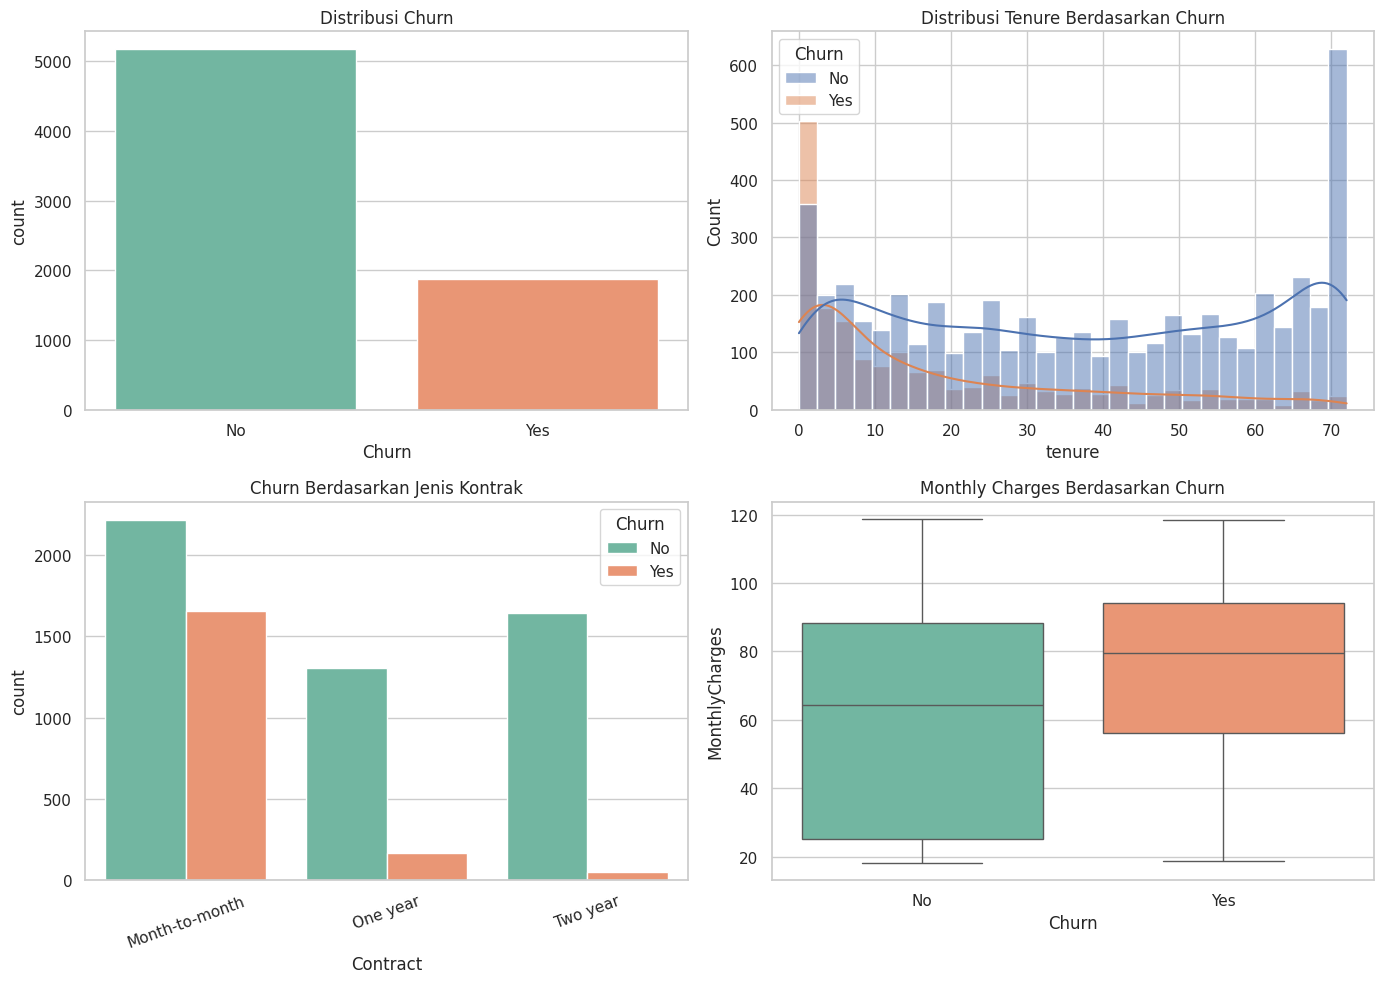

In [19]:
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

sns.countplot(data=df_integrated, x="Churn", hue="Churn", ax=axes[0, 0], palette="Set2", legend=False)
axes[0, 0].set_title("Distribusi Churn")

sns.histplot(data=df_integrated, x="tenure", hue="Churn", kde=True, bins=30, ax=axes[0, 1])
axes[0, 1].set_title("Distribusi Tenure Berdasarkan Churn")

sns.countplot(data=df_integrated, x="Contract", hue="Churn", ax=axes[1, 0], palette="Set2")
axes[1, 0].set_title("Churn Berdasarkan Jenis Kontrak")
axes[1, 0].tick_params(axis="x", rotation=20)

sns.boxplot(data=df_integrated, x="Churn", y="MonthlyCharges", hue="Churn", ax=axes[1, 1], palette="Set2", legend=False)
axes[1, 1].set_title("Monthly Charges Berdasarkan Churn")

plt.tight_layout()
plt.show()

**Catatan Pembelajaran:**  
Cell ini memvisualisasikan churn berdasarkan metode pembayaran. Tujuannya melihat apakah metode pembayaran tertentu berkaitan dengan risiko churn yang lebih tinggi.

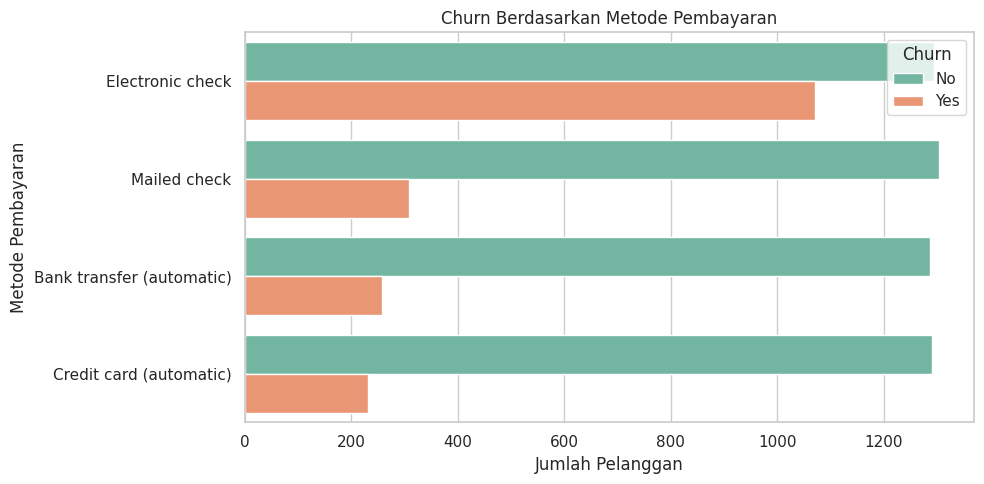

In [20]:
plt.figure(figsize=(10, 5))
sns.countplot(data=df_integrated, y="PaymentMethod", hue="Churn", palette="Set2")
plt.title("Churn Berdasarkan Metode Pembayaran")
plt.xlabel("Jumlah Pelanggan")
plt.ylabel("Metode Pembayaran")
plt.tight_layout()
plt.show()

**Interpretasi Output:**  
Grafik distribusi churn menunjukkan proporsi pelanggan churn dan tidak churn. Grafik tenure menunjukkan apakah pelanggan dengan masa berlangganan rendah lebih banyak churn. Grafik kontrak dan metode pembayaran membantu mengamati kategori pelanggan yang lebih berisiko churn. Boxplot `MonthlyCharges` menunjukkan perbedaan biaya bulanan antara pelanggan churn dan tidak churn.

**Kesimpulan:**  
Visualisasi membantu mengidentifikasi pola awal churn berdasarkan tenure, kontrak, biaya bulanan, dan metode pembayaran.

---

### 2.3 Hasil Penyajian Data Dianalisis Karakteristiknya untuk Telaah Data (deskriptif)

Berdasarkan hasil statistik dan visualisasi awal, beberapa karakteristik penting yang perlu diperhatikan adalah:

- Pelanggan dengan kontrak bulanan cenderung lebih mudah churn karena tidak memiliki ikatan kontrak jangka panjang.
- Pelanggan dengan tenure rendah perlu diperhatikan karena masa awal berlangganan sering menjadi periode kritis.
- Biaya bulanan yang tinggi dapat menjadi salah satu faktor yang berkaitan dengan churn.
- Metode pembayaran tertentu dapat menunjukkan pola risiko churn yang berbeda.
- Distribusi target perlu diperhatikan karena jumlah pelanggan churn biasanya lebih sedikit dibanding pelanggan tidak churn.

**Kesimpulan:**  
Karakteristik data menunjukkan adanya beberapa variabel yang berpotensi kuat memengaruhi churn, terutama `Contract`, `tenure`, `MonthlyCharges`, dan `PaymentMethod`.

---

## 3. Membuat Laporan Telaah Data

### 3.1 Hasil Analisis Didokumentasikan dalam Bentuk Laporan Sesuai dengan Tujuan Teknis (deskriptif)

Laporan telaah data awal:

| Aspek Telaah | Hasil Analisis |
|---|---|
| Struktur data | Dataset memiliki 7043 baris dan 21 kolom. |
| Target | Kolom target adalah `Churn` dengan kategori `Yes` dan `No`. |
| Tipe data | Dataset terdiri dari data numerik dan kategorikal. |
| Variabel penting awal | `tenure`, `Contract`, `MonthlyCharges`, `InternetService`, dan `PaymentMethod`. |
| Risiko data | Kolom `TotalCharges` perlu diperiksa lebih lanjut karena pada dataset asli sering terbaca sebagai object. |
| Kesiapan data | Data siap masuk ke Unit #3 untuk validasi data lebih detail. |

**Kesimpulan:**  
Hasil telaah data telah didokumentasikan dan dapat digunakan sebagai dasar untuk validasi, pembersihan, konstruksi fitur, dan pemodelan.

---

### 3.2 Hipotesis Disusun Berdasar Hasil Analisis Sesuai Tujuan Teknis Data Science (deskriptif)

Hipotesis awal berdasarkan telaah data:

1. Pelanggan dengan kontrak `Month-to-month` memiliki kemungkinan churn lebih tinggi dibanding pelanggan dengan kontrak satu tahun atau dua tahun.
2. Pelanggan dengan `tenure` rendah memiliki risiko churn lebih tinggi karena belum memiliki loyalitas yang kuat terhadap layanan.
3. Pelanggan dengan `MonthlyCharges` tinggi lebih berpotensi churn jika nilai layanan yang diterima tidak dianggap sebanding.
4. Pelanggan yang menggunakan metode pembayaran tertentu, seperti electronic check, kemungkinan memiliki pola churn lebih tinggi.
5. Layanan tambahan seperti `OnlineSecurity`, `TechSupport`, dan `OnlineBackup` dapat berhubungan dengan penurunan risiko churn karena meningkatkan nilai layanan.

**Kesimpulan Unit #2:**  
Telaah data menunjukkan bahwa dataset memiliki struktur yang sesuai untuk analisis churn. Beberapa variabel menunjukkan potensi hubungan dengan churn dan akan divalidasi lebih lanjut pada Unit #3.

<a id="unit3"></a>

# UNIT #3 - Memvalidasi Data
### Kode Unit: J.62DMI00.006.1

[? Kembali ke Daftar Isi](#daftar-isi)

---

## 1. Melakukan Pengecekan Kelengkapan Data

### 1.1 Penilaian Kualitas Data dari Hasil Telaah Disajikan Sesuai Tujuan Teknis Data Science (kode)

Penilaian kualitas data dilakukan untuk mengetahui apakah dataset layak digunakan untuk analisis dan pemodelan. Aspek yang diperiksa meliputi missing value, duplikasi, tipe data, konsistensi label target, dan potensi masalah pada kolom `TotalCharges`.

**Catatan Pembelajaran:**  
Cell ini membuat salinan data untuk proses validasi. Salinan digunakan agar tahap validasi terdokumentasi tanpa mengubah DataFrame hasil integrasi secara langsung.

In [21]:
# Menyalin data hasil integrasi untuk tahap validasi
df_validasi = df_integrated.copy()

# Pemeriksaan nilai kosong standar
missing_summary = pd.DataFrame({
    "Kolom": df_validasi.columns,
    "Missing Value": df_validasi.isna().sum().values,
    "Persentase Missing (%)": (df_validasi.isna().sum().values / len(df_validasi) * 100).round(2)
})

missing_summary.sort_values("Missing Value", ascending=False)

,Kolom,Missing Value,Persentase Missing (%)
0,customerID,0,0.0
1,gender,0,0.0
2,SeniorCitizen,0,0.0
3,Partner,0,0.0
4,Dependents,0,0.0
5,tenure,0,0.0
6,PhoneService,0,0.0
7,MultipleLines,0,0.0
8,InternetService,0,0.0
9,OnlineSecurity,0,0.0


**Catatan Pembelajaran:**  
Cell ini mencari nilai kosong yang berbentuk spasi pada kolom teks. Ini penting karena spasi kosong sering tidak terbaca sebagai missing value standar oleh Pandas.

In [22]:
# Pemeriksaan nilai kosong berbentuk spasi pada kolom kategorikal/object
blank_string_summary = []

validasi_object_columns = [
    column for column in df_validasi.columns
    if pd.api.types.is_object_dtype(df_validasi[column])
    or pd.api.types.is_string_dtype(df_validasi[column])
]

for column in validasi_object_columns:
    blank_count = df_validasi[column].astype(str).str.strip().eq("").sum()
    blank_string_summary.append({
        "Kolom": column,
        "Blank String": blank_count,
        "Persentase Blank (%)": round(blank_count / len(df_validasi) * 100, 2)
    })

blank_string_summary = pd.DataFrame(blank_string_summary)
blank_string_summary.sort_values("Blank String", ascending=False)

,Kolom,Blank String,Persentase Blank (%)
16,TotalCharges,11,0.16
0,customerID,0,0.00
1,gender,0,0.00
2,Partner,0,0.00
4,PhoneService,0,0.00
3,Dependents,0,0.00
6,InternetService,0,0.00
7,OnlineSecurity,0,0.00
8,OnlineBackup,0,0.00
5,MultipleLines,0,0.00


**Catatan Pembelajaran:**  
Cell ini membuat ringkasan penilaian kualitas data. Kolom `Penilaian` membantu menunjukkan aspek mana yang sudah sesuai dan mana yang perlu koreksi.

In [23]:
# Ringkasan kualitas data
quality_assessment = pd.DataFrame({
    "Aspek Kualitas": [
        "Jumlah baris",
        "Jumlah kolom",
        "Duplikasi baris",
        "Keunikan customerID",
        "Kolom target tersedia",
        "Nilai target valid",
        "Kolom TotalCharges bertipe numerik"
    ],
    "Hasil Pemeriksaan": [
        df_validasi.shape[0],
        df_validasi.shape[1],
        df_validasi.duplicated().sum(),
        df_validasi["customerID"].is_unique if "customerID" in df_validasi.columns else False,
        "Churn" in df_validasi.columns,
        set(df_validasi["Churn"].dropna().unique()).issubset({"Yes", "No"}),
        pd.api.types.is_numeric_dtype(df_validasi["TotalCharges"])
    ],
    "Penilaian": [
        "Sesuai" if df_validasi.shape[0] == 7043 else "Perlu diperiksa",
        "Sesuai" if df_validasi.shape[1] == 21 else "Perlu diperiksa",
        "Sesuai" if df_validasi.duplicated().sum() == 0 else "Perlu koreksi",
        "Sesuai" if ("customerID" in df_validasi.columns and df_validasi["customerID"].is_unique) else "Perlu koreksi",
        "Sesuai" if "Churn" in df_validasi.columns else "Perlu koreksi",
        "Sesuai" if set(df_validasi["Churn"].dropna().unique()).issubset({"Yes", "No"}) else "Perlu koreksi",
        "Sesuai" if pd.api.types.is_numeric_dtype(df_validasi["TotalCharges"]) else "Perlu koreksi"
    ]
})

quality_assessment

,Aspek Kualitas,Hasil Pemeriksaan,Penilaian
0,Jumlah baris,7043,Sesuai
1,Jumlah kolom,21,Sesuai
2,Duplikasi baris,0,Sesuai
3,Keunikan customerID,True,Sesuai
4,Kolom target tersedia,True,Sesuai
5,Nilai target valid,True,Sesuai
6,Kolom TotalCharges bertipe numerik,False,Perlu koreksi


**Interpretasi Output:**  
Tabel missing value menunjukkan apakah ada nilai kosong standar pada setiap kolom. Tabel blank string digunakan karena pada dataset Telco, kolom `TotalCharges` sering memiliki nilai kosong berbentuk spasi sehingga tidak terdeteksi sebagai missing value biasa. Ringkasan kualitas data menunjukkan aspek mana yang sudah sesuai dan mana yang perlu dikoreksi.

**Kesimpulan:**  
Kualitas data secara umum baik jika tidak ada duplikasi, `customerID` unik, target `Churn` valid, dan struktur data sesuai. Namun kolom `TotalCharges` perlu perhatian khusus jika masih bertipe object atau memiliki blank string.

---

### 1.2 Penilaian Tingkat Kecukupan Data dari Hasil Telaah Disajikan Sesuai Tujuan Teknis Data Science (kode)

Kecukupan data dinilai berdasarkan jumlah observasi, jumlah fitur, kelengkapan label target, dan distribusi kelas target. Data dianggap cukup apabila memiliki jumlah baris memadai dan target memiliki dua kelas yang dapat dipelajari oleh model klasifikasi.

**Catatan Pembelajaran:**  
Cell ini menilai apakah jumlah data, jumlah atribut, dan distribusi target cukup untuk pemodelan. Ini menjawab apakah dataset layak dipakai untuk klasifikasi churn.

In [24]:
target_count = df_validasi["Churn"].value_counts()
target_percentage = (df_validasi["Churn"].value_counts(normalize=True) * 100).round(2)

kecukupan_data = pd.DataFrame({
    "Aspek Kecukupan": [
        "Jumlah observasi",
        "Jumlah atribut",
        "Jumlah kelas target",
        "Persentase kelas mayoritas",
        "Persentase kelas minoritas",
        "Label target kosong"
    ],
    "Nilai": [
        df_validasi.shape[0],
        df_validasi.shape[1],
        df_validasi["Churn"].nunique(),
        target_percentage.max(),
        target_percentage.min(),
        df_validasi["Churn"].isna().sum()
    ],
    "Penilaian": [
        "Cukup" if df_validasi.shape[0] >= 1000 else "Kurang",
        "Cukup" if df_validasi.shape[1] >= 10 else "Kurang",
        "Cukup" if df_validasi["Churn"].nunique() == 2 else "Kurang",
        "Perlu diperhatikan" if target_percentage.max() > 70 else "Seimbang",
        "Perlu diperhatikan" if target_percentage.min() < 30 else "Seimbang",
        "Cukup" if df_validasi["Churn"].isna().sum() == 0 else "Perlu koreksi"
    ]
})

kecukupan_data

,Aspek Kecukupan,Nilai,Penilaian
0,Jumlah observasi,7043.00,Cukup
1,Jumlah atribut,21.00,Cukup
2,Jumlah kelas target,2.00,Cukup
3,Persentase kelas mayoritas,73.46,Perlu diperhatikan
4,Persentase kelas minoritas,26.54,Perlu diperhatikan
5,Label target kosong,0.00,Cukup


**Catatan Pembelajaran:**  
Cell ini menampilkan distribusi target churn secara visual. Grafik ini berguna untuk menjelaskan ketidakseimbangan kelas kepada penguji.

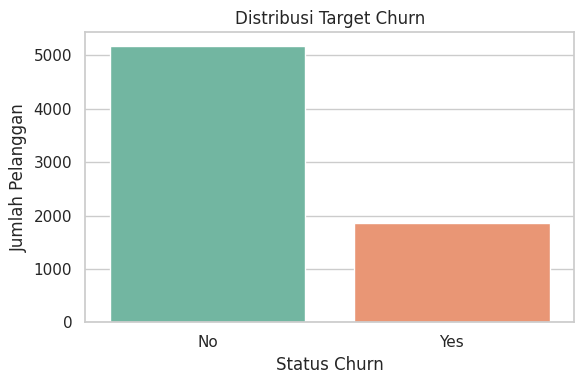

In [25]:
plt.figure(figsize=(6, 4))
sns.countplot(data=df_validasi, x="Churn", hue="Churn", palette="Set2", legend=False)
plt.title("Distribusi Target Churn")
plt.xlabel("Status Churn")
plt.ylabel("Jumlah Pelanggan")
plt.tight_layout()
plt.show()

**Interpretasi Output:**  
Dataset memiliki jumlah observasi yang cukup untuk pemodelan klasifikasi. Distribusi target perlu diperhatikan karena kelas `No` biasanya lebih dominan dibanding kelas `Yes`, sehingga evaluasi model tidak cukup hanya menggunakan accuracy.

**Kesimpulan:**  
Tingkat kecukupan data dinilai memadai untuk machine learning, tetapi ketidakseimbangan kelas perlu dipertimbangkan pada tahap pemodelan dan evaluasi.

---

## 2. Membuat Rekomendasi Kelengkapan Data

### 2.1 Rekomendasi Hasil Penilaian Kualitas Disusun Sesuai Tujuan Teknis Data Science (deskriptif)

Berdasarkan pemeriksaan kualitas data, rekomendasi yang diberikan adalah:

| Temuan Kualitas Data | Rekomendasi |
|---|---|
| `TotalCharges` berpotensi terbaca sebagai object | Konversi `TotalCharges` menjadi numerik menggunakan `pd.to_numeric()`. |
| Blank string pada `TotalCharges` | Ubah blank string menjadi missing value, lalu lakukan imputasi sesuai konteks bisnis. |
| `customerID` tidak relevan sebagai prediktor | Gunakan hanya sebagai identitas data, bukan fitur model. |
| Target `Churn` berbentuk kategorikal | Encode target menjadi format biner pada tahap label definition/modeling. |
| Data kategorikal dominan | Lakukan encoding sebelum model Random Forest dibangun. |

**Kesimpulan:**  
Rekomendasi kualitas data berfokus pada koreksi tipe data, penanganan nilai kosong, dan persiapan data agar kompatibel dengan algoritma machine learning.

---

### 2.2 Rekomendasi Hasil Penilaian Kecukupan Data Disusun Sesuai Tujuan Teknis Data Science (deskriptif)

Berdasarkan penilaian kecukupan data, rekomendasi yang diberikan adalah:

| Temuan Kecukupan Data | Rekomendasi |
|---|---|
| Jumlah data 7043 baris | Data cukup untuk membangun model klasifikasi awal. |
| Jumlah fitur 21 kolom | Fitur cukup beragam untuk menjelaskan perilaku churn. |
| Distribusi target tidak sepenuhnya seimbang | Gunakan metrik precision, recall, dan F1-score selain accuracy. |
| Target memiliki dua kelas | Model klasifikasi biner sesuai untuk tujuan teknis. |
| Data berasal dari satu sumber | Tidak perlu integrasi sumber tambahan pada project awal. |

**Kesimpulan Unit #3:**  
Data cukup untuk digunakan dalam project klasifikasi churn. Beberapa isu kualitas seperti `TotalCharges` dan ketidakseimbangan target perlu ditangani pada unit berikutnya.

<a id="unit4"></a>

# UNIT #4 - Menentukan Objek Data
### Kode Unit: J.62DMI00.007.1

[? Kembali ke Daftar Isi](#daftar-isi)

---

## 1. Memutuskan Kriteria dan Teknik Pemilihan Data

### 1.1 Kriteria Pemilihan Data Diidentifikasi Sesuai dengan Tujuan Teknis dan Aturan yang Berlaku (deskriptif)

Kriteria pemilihan data ditentukan berdasarkan tujuan teknis, yaitu membangun model klasifikasi churn. Data yang dipilih harus relevan dengan perilaku pelanggan, layanan yang digunakan, kontrak, pembayaran, dan status churn.

Kriteria pemilihan data:

| Kriteria | Penjelasan |
|---|---|
| Relevan dengan churn | Kolom harus memiliki potensi hubungan dengan keputusan pelanggan untuk berhenti. |
| Memiliki nilai informatif | Kolom tidak hanya berfungsi sebagai identitas unik. |
| Memiliki target valid | Baris harus memiliki label `Churn`. |
| Dapat diproses oleh model | Kolom numerik dan kategorikal dapat dibersihkan serta diencoding. |
| Sesuai aturan penggunaan | Dataset publik Kaggle digunakan untuk pembelajaran dan penelitian. |

**Kesimpulan:**  
Kriteria pemilihan data diarahkan untuk mempertahankan atribut yang relevan terhadap churn dan mengeluarkan atribut identitas seperti `customerID` dari fitur model.

---

### 1.2 Teknik Pemilihan Data Ditetapkan Sesuai dengan Kriteria Pemilihan Data (deskriptif + kode)

Teknik pemilihan data yang digunakan adalah pemilihan kolom berbasis relevansi bisnis dan teknis. Kolom `customerID` tidak digunakan sebagai fitur prediktor karena hanya berfungsi sebagai identitas unik pelanggan.

**Catatan Pembelajaran:**  
Cell ini menentukan fitur model dengan mengeluarkan `customerID` dan `Churn`. `customerID` dikeluarkan karena hanya identitas, sedangkan `Churn` dipisahkan sebagai target.

In [26]:
target_column = "Churn"
id_column = "customerID"

selected_feature_columns = [
    column for column in df_validasi.columns
    if column not in [id_column, target_column]
]

selected_columns = selected_feature_columns + [target_column]

selection_summary = pd.DataFrame({
    "Komponen": ["Kolom ID", "Kolom target", "Jumlah fitur terpilih", "Jumlah kolom data model"],
    "Nilai": [id_column, target_column, len(selected_feature_columns), len(selected_columns)]
})

selection_summary

,Komponen,Nilai
0,Kolom ID,customerID
1,Kolom target,Churn
2,Jumlah fitur terpilih,19
3,Jumlah kolom data model,20


**Interpretasi Output:**  
Output menunjukkan `customerID` diperlakukan sebagai kolom identitas, `Churn` sebagai target, dan kolom lainnya sebagai kandidat fitur untuk model.

**Kesimpulan:**  
Teknik pemilihan data menggunakan pendekatan supervised learning, yaitu memisahkan fitur prediktor dan target label.

---

## 2. Menentukan Attributes (Columns) dan Records (Row) Data

### 2.1 Attributes (Columns) Data Diidentifikasi Sesuai dengan Kriteria Pemilihan Data (kode)

Attributes atau kolom yang dipilih adalah semua kolom yang relevan untuk prediksi churn, kecuali `customerID` sebagai identitas unik.

**Catatan Pembelajaran:**  
Cell ini mendokumentasikan kolom yang dipilih, peran kolom, tipe data, dan jumlah nilai unik. Ini menjawab bagian attributes atau columns pada Unit #4.

In [27]:
attributes_selected = pd.DataFrame({
    "Kolom Terpilih": selected_columns,
    "Peran": ["Target" if column == target_column else "Fitur" for column in selected_columns],
    "Tipe Data": [str(df_validasi[column].dtype) for column in selected_columns],
    "Jumlah Nilai Unik": [df_validasi[column].nunique() for column in selected_columns]
})

attributes_selected

,Kolom Terpilih,Peran,Tipe Data,Jumlah Nilai Unik
0,gender,Fitur,str,2
1,SeniorCitizen,Fitur,int64,2
2,Partner,Fitur,str,2
3,Dependents,Fitur,str,2
4,tenure,Fitur,int64,73
5,PhoneService,Fitur,str,2
6,MultipleLines,Fitur,str,3
7,InternetService,Fitur,str,3
8,OnlineSecurity,Fitur,str,3
9,OnlineBackup,Fitur,str,3


**Interpretasi Output:**  
Tabel menunjukkan daftar kolom yang digunakan dalam data model, peran masing-masing kolom, tipe data, dan jumlah nilai unik.

**Kesimpulan:**  
Attributes yang dipilih sudah sesuai untuk kebutuhan klasifikasi churn karena mencakup fitur pelanggan, layanan, kontrak, pembayaran, dan target.

---

### 2.2 Records (Row) Data Diidentifikasi Sesuai dengan Kriteria Pemilihan Data (kode)

Records atau baris yang digunakan adalah data pelanggan yang memiliki label target valid. Pada tahap ini dilakukan pemeriksaan jumlah baris sebelum dan sesudah seleksi.

**Catatan Pembelajaran:**  
Cell ini membuat `df_selected`, yaitu data yang sudah dipilih berdasarkan fitur dan target valid. Data ini menjadi input untuk tahap pembersihan.

In [28]:
df_selected = df_validasi[selected_columns].copy()

# Memilih hanya record dengan target Churn valid
valid_target_values = ["Yes", "No"]
df_selected = df_selected[df_selected[target_column].isin(valid_target_values)].copy()

record_selection_summary = pd.DataFrame({
    "Tahap": ["Data awal", "Data setelah seleksi kolom dan target valid"],
    "Jumlah Baris": [len(df_validasi), len(df_selected)],
    "Jumlah Kolom": [df_validasi.shape[1], df_selected.shape[1]]
})

record_selection_summary

,Tahap,Jumlah Baris,Jumlah Kolom
0,Data awal,7043,21
1,Data setelah seleksi kolom dan target valid,7043,20


**Interpretasi Output:**  
Jika jumlah baris tidak berubah, berarti semua record memiliki label target yang valid. Jika berkurang, berarti ada record yang tidak memenuhi kriteria dan dikeluarkan dari data model.

**Kesimpulan Unit #4:**  
Objek data telah ditentukan dalam bentuk `df_selected`, yaitu dataset yang berisi fitur relevan dan target `Churn` tanpa kolom identitas `customerID`.

<a id="unit5"></a>

# UNIT #5 - Membersihkan Data
### Kode Unit: J.62DMI00.008.1

[? Kembali ke Daftar Isi](#daftar-isi)

---

## 1. Melakukan Pembersihan Data yang Kotor

### 1.1 Strategi Pembersihan Data Ditentukan Berdasarkan Hasil Telaah Data (deskriptif)

Strategi pembersihan data ditentukan berdasarkan hasil validasi pada Unit #3 dan objek data pada Unit #4.

Strategi yang digunakan:

| Masalah Data | Strategi Pembersihan |
|---|---|
| Blank string pada kolom object | Menghapus spasi awal/akhir dengan `str.strip()`. |
| `TotalCharges` bertipe object | Mengubah `TotalCharges` menjadi numerik. |
| Nilai kosong pada `TotalCharges` | Mengisi dengan `0` jika berhubungan dengan pelanggan baru/tenure 0. |
| Duplikasi data | Menghapus duplikasi jika ditemukan. |
| Target tidak valid | Mempertahankan hanya target `Yes` dan `No`. |

**Kesimpulan:**  
Strategi pembersihan difokuskan pada koreksi tipe data, penanganan nilai kosong, dan konsistensi record untuk pemodelan.

---

### 1.2 Data yang Kotor Dikoreksi Berdasarkan Strategi Pembersihan Data (kode)

Tahap ini menghasilkan DataFrame bersih bernama `df_clean`.

**Catatan Pembelajaran:**  
Cell ini melakukan pembersihan utama: menghapus spasi kategori, mengubah `TotalCharges` menjadi numerik, mengisi nilai kosong, menghapus duplikasi, dan memastikan target valid.

In [29]:
df_clean = df_selected.copy()

# Menghapus spasi awal/akhir pada seluruh kolom object
object_columns = [
    column for column in df_clean.columns
    if pd.api.types.is_object_dtype(df_clean[column])
    or pd.api.types.is_string_dtype(df_clean[column])
]
for column in object_columns:
    df_clean[column] = df_clean[column].astype(str).str.strip()

# Mengonversi TotalCharges menjadi numerik
if "TotalCharges" in df_clean.columns:
    df_clean["TotalCharges"] = pd.to_numeric(df_clean["TotalCharges"], errors="coerce")

# Mengisi TotalCharges kosong. Pada dataset Telco, nilai kosong umumnya terjadi pada tenure 0.
if "TotalCharges" in df_clean.columns:
    df_clean["TotalCharges"] = df_clean["TotalCharges"].fillna(0)

# Menghapus duplikasi jika ada
df_clean = df_clean.drop_duplicates().copy()

# Memastikan target hanya berisi Yes dan No
df_clean = df_clean[df_clean["Churn"].isin(["Yes", "No"])].copy()

print("Ukuran data sebelum cleaning:", df_selected.shape)
print("Ukuran data setelah cleaning:", df_clean.shape)
print("Tipe data TotalCharges:", df_clean["TotalCharges"].dtype if "TotalCharges" in df_clean.columns else "Kolom tidak tersedia")

Ukuran data sebelum cleaning: (7043, 20)
Ukuran data setelah cleaning: (7021, 20)
Tipe data TotalCharges: float64


**Catatan Pembelajaran:**  
Cell ini mengevaluasi hasil cleaning. Jika missing value dan duplikasi bernilai 0 serta `TotalCharges` numerik, maka data sudah lebih siap untuk konstruksi fitur.

In [30]:
cleaning_check = pd.DataFrame({
    "Pemeriksaan": [
        "Missing value total",
        "Duplikasi baris",
        "Target valid",
        "TotalCharges numerik",
        "Jumlah baris akhir"
    ],
    "Hasil": [
        df_clean.isna().sum().sum(),
        df_clean.duplicated().sum(),
        set(df_clean["Churn"].unique()).issubset({"Yes", "No"}),
        pd.api.types.is_numeric_dtype(df_clean["TotalCharges"]) if "TotalCharges" in df_clean.columns else False,
        df_clean.shape[0]
    ]
})

cleaning_check

,Pemeriksaan,Hasil
0,Missing value total,0
1,Duplikasi baris,0
2,Target valid,True
3,TotalCharges numerik,True
4,Jumlah baris akhir,7021


**Interpretasi Output:**  
Output menunjukkan perubahan ukuran data sebelum dan sesudah cleaning. Tabel pemeriksaan memastikan tidak ada missing value total, tidak ada duplikasi, target valid, dan `TotalCharges` sudah numerik.

**Kesimpulan:**  
Data kotor telah dikoreksi berdasarkan strategi pembersihan. Data bersih disimpan dalam `df_clean` untuk digunakan pada tahap konstruksi data dan pemodelan.

---

## 2. Membuat Laporan dan Rekomendasi Hasil Membersihkan Data

### 2.1 Masalah dan Teknis Koreksi Data Dideskripsikan Sesuai dengan Kondisi Data dan Strategi Pembersihan Data (deskriptif + kode)

Masalah dan koreksi data dirangkum untuk mendokumentasikan tindakan cleaning yang telah dilakukan.

**Catatan Pembelajaran:**  
Cell ini membuat laporan masalah data dan teknik koreksinya. Laporan ini berguna untuk presentasi karena menunjukkan alasan setiap tindakan cleaning.

In [31]:
cleaning_report = pd.DataFrame({
    "Masalah Data": [
        "Spasi tersembunyi pada kolom object",
        "TotalCharges terbaca sebagai object",
        "TotalCharges memiliki nilai kosong/blank",
        "Kemungkinan duplikasi baris",
        "Kolom customerID tidak digunakan sebagai fitur"
    ],
    "Teknik Koreksi": [
        "Menggunakan str.strip() pada kolom object",
        "Menggunakan pd.to_numeric(errors='coerce')",
        "Mengisi nilai kosong dengan 0",
        "Menggunakan drop_duplicates()",
        "Dihapus pada Unit #4 saat seleksi fitur"
    ],
    "Alasan Bisnis/Teknis": [
        "Agar kategori tidak terpecah karena perbedaan spasi",
        "Agar dapat digunakan sebagai fitur numerik",
        "Nilai kosong umumnya merepresentasikan pelanggan baru dengan tenure 0",
        "Mencegah pelanggan yang sama dihitung lebih dari sekali",
        "ID unik tidak memiliki pola prediktif untuk churn"
    ]
})

cleaning_report

,Masalah Data,Teknik Koreksi,Alasan Bisnis/Teknis
0,Spasi tersembunyi pada kolom object,Menggunakan str.strip() pada kolom object,Agar kategori tidak terpecah karena perbedaan ...
1,TotalCharges terbaca sebagai object,Menggunakan pd.to_numeric(errors='coerce'),Agar dapat digunakan sebagai fitur numerik
2,TotalCharges memiliki nilai kosong/blank,Mengisi nilai kosong dengan 0,Nilai kosong umumnya merepresentasikan pelangg...
3,Kemungkinan duplikasi baris,Menggunakan drop_duplicates(),Mencegah pelanggan yang sama dihitung lebih da...
4,Kolom customerID tidak digunakan sebagai fitur,Dihapus pada Unit #4 saat seleksi fitur,ID unik tidak memiliki pola prediktif untuk churn


**Interpretasi Output:**  
Laporan menunjukkan masalah data yang ditemukan, teknik koreksi yang digunakan, dan alasan teknis atau bisnis dari setiap tindakan.

**Kesimpulan:**  
Dokumentasi koreksi data membantu memastikan proses cleaning dapat ditelusuri dan dipertanggungjawabkan.

---

### 2.2 Evaluasi Dihasilkan Berdasarkan Analisis Koreksi yang Telah Dilakukan (kode + deskriptif)

Evaluasi dilakukan dengan membandingkan kondisi data sebelum dan sesudah cleaning.

**Catatan Pembelajaran:**  
Cell ini membandingkan kondisi sebelum dan sesudah cleaning. Tujuannya membuktikan bahwa proses pembersihan memberikan perubahan yang terukur.

In [32]:
evaluation_cleaning = pd.DataFrame({
    "Indikator": [
        "Jumlah baris",
        "Jumlah kolom",
        "Total missing value",
        "Total duplikasi",
        "Tipe data TotalCharges"
    ],
    "Sebelum Cleaning": [
        df_selected.shape[0],
        df_selected.shape[1],
        df_selected.isna().sum().sum(),
        df_selected.duplicated().sum(),
        str(df_selected["TotalCharges"].dtype) if "TotalCharges" in df_selected.columns else "Tidak tersedia"
    ],
    "Sesudah Cleaning": [
        df_clean.shape[0],
        df_clean.shape[1],
        df_clean.isna().sum().sum(),
        df_clean.duplicated().sum(),
        str(df_clean["TotalCharges"].dtype) if "TotalCharges" in df_clean.columns else "Tidak tersedia"
    ]
})

evaluation_cleaning

,Indikator,Sebelum Cleaning,Sesudah Cleaning
0,Jumlah baris,7043,7021
1,Jumlah kolom,20,20
2,Total missing value,0,0
3,Total duplikasi,22,0
4,Tipe data TotalCharges,str,float64


**Interpretasi Output:**  
Tabel evaluasi memperlihatkan dampak cleaning terhadap jumlah baris, jumlah kolom, missing value, duplikasi, dan tipe data `TotalCharges`.

**Kesimpulan:**  
Cleaning berhasil jika missing value dan duplikasi bernilai 0 serta `TotalCharges` sudah berubah menjadi tipe numerik.

---

### 2.3 Evaluasi Proses dan Hasilnya Didokumentasikan (deskriptif)

Hasil dokumentasi proses cleaning:

| Tahap | Hasil |
|---|---|
| Seleksi data | Data model disimpan sebagai `df_selected`. |
| Koreksi format teks | Spasi pada kolom kategorikal dibersihkan. |
| Koreksi tipe data | `TotalCharges` dikonversi menjadi numerik. |
| Penanganan missing value | Nilai kosong pada `TotalCharges` diisi dengan 0. |
| Penghapusan duplikasi | Duplikasi dihapus jika ditemukan. |
| Output akhir | Data bersih disimpan sebagai `df_clean`. |

Rekomendasi lanjutan:

1. Lakukan encoding fitur kategorikal pada Unit #6.
2. Buat fitur tambahan seperti kelompok tenure atau rasio biaya jika diperlukan.
3. Pisahkan fitur dan label sebelum pemodelan.
4. Gunakan metrik precision, recall, dan F1-score karena distribusi target tidak sepenuhnya seimbang.

**Kesimpulan Unit #5:**  
Data telah dibersihkan dan siap digunakan pada Unit #6 untuk konstruksi data. Output utama dari tahap ini adalah `df_clean`, yaitu dataset yang sudah dikoreksi dan konsisten untuk proses machine learning.

<a id="unit6"></a>

# UNIT #6 - Mengkonstruksi Data
### Kode Unit: J.62DMI00.009.1

[Kembali ke Daftar Isi](#daftar-isi)

---

## 1. Menganalisis Teknik Transformasi Data

### 1.1 Analisis Data untuk Menentukan Representasi Fitur Data Awal (kode + deskriptif)

Pada tahap ini, data bersih `df_clean` dianalisis untuk menentukan representasi fitur awal yang akan digunakan dalam pemodelan. Fitur awal terdiri dari fitur numerik dan fitur kategorikal.

**Catatan Pembelajaran:**  
Cell ini memulai Unit #6 dengan membuat salinan data bersih untuk konstruksi fitur. Ringkasan fitur membantu menentukan representasi awal sebelum feature engineering.

In [33]:
df_konstruksi = df_clean.copy()

feature_overview = pd.DataFrame({
    "Kolom": df_konstruksi.columns,
    "Tipe Data": df_konstruksi.dtypes.astype(str).values,
    "Jumlah Nilai Unik": df_konstruksi.nunique().values,
    "Contoh Nilai": [", ".join(map(str, df_konstruksi[col].dropna().unique()[:4])) for col in df_konstruksi.columns]
})

feature_overview

,Kolom,Tipe Data,Jumlah Nilai Unik,Contoh Nilai
0,gender,str,2,"Female, Male"
1,SeniorCitizen,int64,2,"0, 1"
2,Partner,str,2,"Yes, No"
3,Dependents,str,2,"No, Yes"
4,tenure,int64,73,"1, 34, 2, 45"
5,PhoneService,str,2,"No, Yes"
6,MultipleLines,str,3,"No phone service, No, Yes"
7,InternetService,str,3,"DSL, Fiber optic, No"
8,OnlineSecurity,str,3,"No, Yes, No internet service"
9,OnlineBackup,str,3,"Yes, No, No internet service"


**Catatan Pembelajaran:**  
Cell ini mengidentifikasi fitur numerik dan kategorikal setelah cleaning. Informasi ini menentukan teknik transformasi yang akan dipakai pada tahap pemodelan.

In [34]:
target_column = "Churn"

initial_numeric_features = df_konstruksi.drop(columns=[target_column]).select_dtypes(include=["number"]).columns.tolist()
initial_categorical_features = [
    column for column in df_konstruksi.drop(columns=[target_column]).columns
    if column not in initial_numeric_features
]

print("Fitur numerik awal:")
print(initial_numeric_features)

print("Fitur kategorikal awal:")
print(initial_categorical_features)

Fitur numerik awal:
['SeniorCitizen', 'tenure', 'MonthlyCharges', 'TotalCharges']
Fitur kategorikal awal:
['gender', 'Partner', 'Dependents', 'PhoneService', 'MultipleLines', 'InternetService', 'OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 'TechSupport', 'StreamingTV', 'StreamingMovies', 'Contract', 'PaperlessBilling', 'PaymentMethod']


**Interpretasi Output:**  
Output menunjukkan representasi fitur awal setelah data dibersihkan. Fitur numerik dapat digunakan sebagai nilai angka, sedangkan fitur kategorikal perlu diubah menjadi representasi numerik melalui encoding pada tahap pemodelan.

**Kesimpulan:**  
Representasi fitur awal sudah jelas: data memiliki fitur numerik seperti `tenure`, `MonthlyCharges`, dan `TotalCharges`, serta fitur kategorikal seperti `Contract`, `InternetService`, dan `PaymentMethod`.

---

### 1.2 Analisis Representasi Fitur Data Awal untuk Menentukan Teknik Rekayasa Fitur yang Diperlukan untuk Pembangunan Model Data Science (deskriptif)

Berdasarkan fitur awal, beberapa rekayasa fitur diperlukan untuk memperkuat informasi bisnis yang mungkin berhubungan dengan churn.

| Fitur Awal | Teknik Rekayasa Fitur | Alasan |
|---|---|---|
| `tenure` | Membuat kelompok tenure | Risiko churn dapat berbeda pada pelanggan baru, menengah, dan lama. |
| `MonthlyCharges` | Membuat kategori biaya bulanan | Memudahkan model menangkap kelompok pelanggan dengan biaya rendah, sedang, atau tinggi. |
| `TotalCharges` dan `tenure` | Membuat rata-rata biaya per bulan historis | Menggambarkan beban biaya historis pelanggan. |
| Layanan internet | Membuat indikator penggunaan internet | Pelanggan dengan layanan internet memiliki pola churn yang berbeda. |
| Layanan tambahan | Membuat indikator penggunaan support/security/backup | Layanan tambahan dapat berkaitan dengan kepuasan dan loyalitas pelanggan. |
| Metode pembayaran | Membuat indikator pembayaran otomatis | Pembayaran otomatis dapat menurunkan risiko churn. |

**Kesimpulan:**  
Rekayasa fitur dilakukan untuk mengubah informasi layanan dan biaya menjadi fitur yang lebih mudah dipelajari oleh model Random Forest.

---

## 2. Melakukan Transformasi Data

### 2.1 Transformasi Dilakukan untuk Mendapatkan Fitur Data Awal (kode)

Transformasi awal dilakukan dengan memastikan fitur numerik bertipe numerik, fitur kategorikal bertipe teks, dan target tetap tersedia untuk tahap pelabelan.

**Catatan Pembelajaran:**  
Cell ini memisahkan fitur numerik dan kategorikal. Pemisahan ini penting karena fitur numerik dapat langsung dihitung, sedangkan fitur kategorikal perlu encoding sebelum dipakai model machine learning.

In [35]:
df_transformed = df_konstruksi.copy()

# Memastikan fitur numerik utama memiliki tipe numerik
numeric_columns_to_check = ["SeniorCitizen", "tenure", "MonthlyCharges", "TotalCharges"]
for column in numeric_columns_to_check:
    if column in df_transformed.columns:
        df_transformed[column] = pd.to_numeric(df_transformed[column], errors="coerce")

# Memastikan kolom kategorikal bersih dari spasi tambahan
categorical_columns_to_check = [
    column for column in df_transformed.columns
    if column != target_column and not pd.api.types.is_numeric_dtype(df_transformed[column])
]
for column in categorical_columns_to_check:
    df_transformed[column] = df_transformed[column].astype(str).str.strip()

transform_check = pd.DataFrame({
    "Kolom": df_transformed.columns,
    "Tipe Data Setelah Transformasi": df_transformed.dtypes.astype(str).values,
    "Missing Value": df_transformed.isna().sum().values
})

transform_check

,Kolom,Tipe Data Setelah Transformasi,Missing Value
0,gender,str,0
1,SeniorCitizen,int64,0
2,Partner,str,0
3,Dependents,str,0
4,tenure,int64,0
5,PhoneService,str,0
6,MultipleLines,str,0
7,InternetService,str,0
8,OnlineSecurity,str,0
9,OnlineBackup,str,0


**Interpretasi Output:**  
Tabel menunjukkan tipe data setelah transformasi awal. Fitur numerik sudah siap digunakan, sedangkan fitur kategorikal akan diencoding dalam pipeline pemodelan.

**Kesimpulan:**  
Transformasi awal menghasilkan dataset yang lebih konsisten dari sisi tipe data dan siap untuk rekayasa fitur.

---

### 2.2 Rekayasa Fitur Data Dilakukan untuk Mendapatkan Fitur Baru yang Diperlukan untuk Pembangunan Model Data Science (kode)

Pada tahap ini dibuat fitur baru berdasarkan konteks bisnis churn pelanggan.

**Catatan Pembelajaran:**  
Cell ini membuat fitur baru berdasarkan pemahaman bisnis, seperti kelompok tenure, kelompok biaya, indikator layanan, dan indikator pembayaran otomatis. Fitur baru ini membantu model menangkap pola churn lebih baik.

In [36]:
df_featured = df_transformed.copy()

# Kelompok tenure
if "tenure" in df_featured.columns:
    df_featured["tenure_group"] = pd.cut(
        df_featured["tenure"],
        bins=[-1, 12, 24, 48, 72],
        labels=["0-12 bulan", "13-24 bulan", "25-48 bulan", "49-72 bulan"]
    ).astype(str)

# Kelompok biaya bulanan
if "MonthlyCharges" in df_featured.columns:
    df_featured["monthly_charge_group"] = pd.qcut(
        df_featured["MonthlyCharges"],
        q=3,
        labels=["Low", "Medium", "High"],
        duplicates="drop"
    ).astype(str)

# Rata-rata biaya historis per bulan aktif
if {"TotalCharges", "tenure"}.issubset(df_featured.columns):
    df_featured["avg_charges_per_tenure"] = np.where(
        df_featured["tenure"] > 0,
        df_featured["TotalCharges"] / df_featured["tenure"],
        0
    )

# Indikator layanan berbasis bisnis
if "InternetService" in df_featured.columns:
    df_featured["has_internet_service"] = np.where(df_featured["InternetService"] != "No", 1, 0)

if "TechSupport" in df_featured.columns:
    df_featured["has_tech_support"] = np.where(df_featured["TechSupport"] == "Yes", 1, 0)

if "OnlineSecurity" in df_featured.columns:
    df_featured["has_online_security"] = np.where(df_featured["OnlineSecurity"] == "Yes", 1, 0)

if "OnlineBackup" in df_featured.columns:
    df_featured["has_online_backup"] = np.where(df_featured["OnlineBackup"] == "Yes", 1, 0)

if {"StreamingTV", "StreamingMovies"}.issubset(df_featured.columns):
    df_featured["has_streaming_service"] = np.where(
        (df_featured["StreamingTV"] == "Yes") | (df_featured["StreamingMovies"] == "Yes"),
        1,
        0
    )

if "PaymentMethod" in df_featured.columns:
    df_featured["is_auto_payment"] = np.where(
        df_featured["PaymentMethod"].isin(["Bank transfer (automatic)", "Credit card (automatic)"]),
        1,
        0
    )

new_feature_columns = [
    "tenure_group", "monthly_charge_group", "avg_charges_per_tenure",
    "has_internet_service", "has_tech_support", "has_online_security",
    "has_online_backup", "has_streaming_service", "is_auto_payment"
]
new_feature_columns = [column for column in new_feature_columns if column in df_featured.columns]

df_featured[new_feature_columns + [target_column]].head()

,tenure_group,monthly_charge_group,avg_charges_per_tenure,has_internet_service,has_tech_support,has_online_security,has_online_backup,has_streaming_service,is_auto_payment,Churn
0,0-12 bulan,Low,29.850000,1,0,0,1,0,0,No
1,25-48 bulan,Medium,55.573529,1,0,1,0,0,0,No
2,0-12 bulan,Medium,54.075000,1,0,1,1,0,0,Yes
3,25-48 bulan,Low,40.905556,1,1,1,0,0,1,No
4,0-12 bulan,Medium,75.825000,1,0,0,0,0,0,Yes


**Catatan Pembelajaran:**  
Cell ini mendokumentasikan fitur baru yang berhasil dibuat. Dokumentasi ini penting agar proses konstruksi data bisa dijelaskan ulang saat presentasi.

In [37]:
feature_engineering_summary = pd.DataFrame({
    "Fitur Baru": new_feature_columns,
    "Tipe Data": [str(df_featured[column].dtype) for column in new_feature_columns],
    "Jumlah Nilai Unik": [df_featured[column].nunique() for column in new_feature_columns]
})

feature_engineering_summary

,Fitur Baru,Tipe Data,Jumlah Nilai Unik
0,tenure_group,str,4
1,monthly_charge_group,str,3
2,avg_charges_per_tenure,float64,6586
3,has_internet_service,int64,2
4,has_tech_support,int64,2
5,has_online_security,int64,2
6,has_online_backup,int64,2
7,has_streaming_service,int64,2
8,is_auto_payment,int64,2


**Interpretasi Output:**  
Output menampilkan fitur baru yang dibuat dari fitur awal. Fitur baru tersebut merepresentasikan kelompok tenure, kelompok biaya, rata-rata biaya historis, penggunaan layanan, dan metode pembayaran otomatis.

**Kesimpulan:**  
Rekayasa fitur menghasilkan dataset `df_featured` yang lebih kaya informasi dan siap digunakan untuk pelabelan serta pemodelan.

---

## 3. Membuat Dokumentasi Konstruksi Data

### 3.1 Teknis Transformasi Data Dijabarkan dalam Bentuk Tertulis (deskriptif)

Teknis transformasi data yang dilakukan:

| Tahap | Teknik | Output |
|---|---|---|
| Transformasi tipe data | Konversi kolom numerik dengan `pd.to_numeric()` | Fitur numerik konsisten. |
| Pembersihan kategorikal | Menghapus spasi dengan `str.strip()` | Kategori lebih konsisten. |
| Binning tenure | `pd.cut()` | Fitur `tenure_group`. |
| Binning MonthlyCharges | `pd.qcut()` | Fitur `monthly_charge_group`. |
| Rasio biaya | `TotalCharges / tenure` | Fitur `avg_charges_per_tenure`. |
| Indikator layanan | `np.where()` | Fitur biner layanan. |
| Indikator pembayaran | `np.where()` | Fitur `is_auto_payment`. |

**Kesimpulan:**  
Teknik transformasi dipilih berdasarkan kebutuhan model dan interpretasi bisnis terhadap perilaku churn pelanggan.

---

### 3.2 Hasil Transformasi Data dan Rekomendasi Hasil Transformasi Dituangkan dalam Bentuk Tertulis (deskriptif)

Hasil konstruksi data:

- Dataset hasil konstruksi disimpan sebagai `df_featured`.
- Fitur numerik telah konsisten.
- Fitur kategorikal tetap dipertahankan untuk encoding di pipeline model.
- Fitur baru ditambahkan untuk memperkuat informasi bisnis.
- Target `Churn` tetap dipertahankan untuk tahap pelabelan.

Rekomendasi:

1. Gunakan one-hot encoding untuk fitur kategorikal.
2. Gunakan train-test split dengan stratifikasi target.
3. Hindari penggunaan `customerID` karena tidak memiliki makna prediktif.
4. Evaluasi kontribusi fitur baru melalui feature importance.

**Kesimpulan Unit #6:**  
Data telah dikonstruksi menjadi `df_featured`, yaitu dataset yang berisi fitur awal dan fitur baru yang siap digunakan untuk pelabelan dan pembangunan model.

<a id="unit7"></a>

# UNIT #7 - Menentukan Label Data
### Kode Unit: J.62DMI00.010.1

[Kembali ke Daftar Isi](#daftar-isi)

---

## 1. Melakukan Pelabelan Data

### 1.1 Analisis Hasil Pelabelan Data Sejenis yang Sudah Ada Diuraikan Kesesuaiannya dengan SOP Pelabelan (deskriptif)

Dataset sudah memiliki label churn pada kolom `Churn` dengan dua kategori:

| Nilai Label Asli | Makna Bisnis | Label Model |
|---|---|---|
| `No` | Pelanggan tidak churn | 0 |
| `Yes` | Pelanggan churn | 1 |

SOP pelabelan yang digunakan:

1. Label harus berasal dari kolom target resmi, yaitu `Churn`.
2. Label hanya boleh memiliki dua nilai valid: `Yes` dan `No`.
3. Nilai `Yes` dikonversi menjadi 1 karena menunjukkan kejadian churn yang ingin diprediksi.
4. Nilai `No` dikonversi menjadi 0 karena menunjukkan pelanggan tidak churn.
5. Record dengan label tidak valid tidak digunakan dalam pemodelan.

**Kesimpulan:**  
Label yang tersedia sudah sesuai untuk klasifikasi biner karena memiliki dua kategori yang jelas secara bisnis.

---

### 1.2 Pelabelan Data Dilakukan Sesuai dengan SOP Pelabelan (kode)

Pelabelan dilakukan dengan mengubah `Churn` dari bentuk kategorikal menjadi numerik biner.

**Catatan Pembelajaran:**  
Cell ini tidak mencari target baru. Target `Churn` sudah ada, lalu hanya diubah dari `Yes/No` menjadi `1/0` agar bisa diproses oleh model machine learning.

In [38]:
df_labeled = df_featured.copy()

label_mapping = {"No": 0, "Yes": 1}
df_labeled["Churn_Label"] = df_labeled["Churn"].map(label_mapping)

label_check = pd.DataFrame({
    "Label Asli": df_labeled["Churn"].unique(),
    "Label Numerik": [label_mapping[value] for value in df_labeled["Churn"].unique()]
})

label_check

,Label Asli,Label Numerik
0,No,0
1,Yes,1


**Catatan Pembelajaran:**  
Cell ini memisahkan data menjadi `X` sebagai fitur dan `y` sebagai label. Pemisahan ini adalah format standar sebelum melakukan train-test split dan training model.

In [39]:
# Memisahkan fitur dan label untuk pemodelan
X = df_labeled.drop(columns=["Churn", "Churn_Label"])
y = df_labeled["Churn_Label"]

print("Ukuran X:", X.shape)
print("Ukuran y:", y.shape)
print("Nilai unik label:", sorted(y.unique()))

Ukuran X: (7021, 28)
Ukuran y: (7021,)
Nilai unik label: [np.int64(0), np.int64(1)]


**Interpretasi Output:**  
Output menunjukkan bahwa label `No` berhasil dikonversi menjadi 0 dan label `Yes` berhasil dikonversi menjadi 1. Data fitur disimpan sebagai `X`, sedangkan label disimpan sebagai `y`.

**Kesimpulan:**  
Pelabelan sudah dilakukan sesuai SOP dan data siap dibagi menjadi data latih dan data uji.

---

## 2. Membuat Laporan Hasil Pelabelan Data

### 2.1 Statistik Hasil Pelabelan Diuraikan pada Laporan (kode)

Statistik label digunakan untuk melihat jumlah dan persentase masing-masing kelas.

**Catatan Pembelajaran:**  
Cell ini menghitung statistik label setelah encoding. Statistik ini membantu melihat jumlah pelanggan churn dan tidak churn setelah label menjadi numerik.

In [40]:
label_statistics = y.value_counts().rename(index={0: "Tidak Churn", 1: "Churn"}).to_frame("Jumlah")
label_statistics["Persentase (%)"] = (label_statistics["Jumlah"] / len(y) * 100).round(2)
label_statistics

,Jumlah,Persentase (%)
Churn_Label,,
Tidak Churn,5164,73.55
Churn,1857,26.45


**Catatan Pembelajaran:**  
Cell ini membuat grafik distribusi label. Grafik ini membantu menjelaskan apakah target relatif seimbang atau perlu perhatian khusus pada evaluasi model.

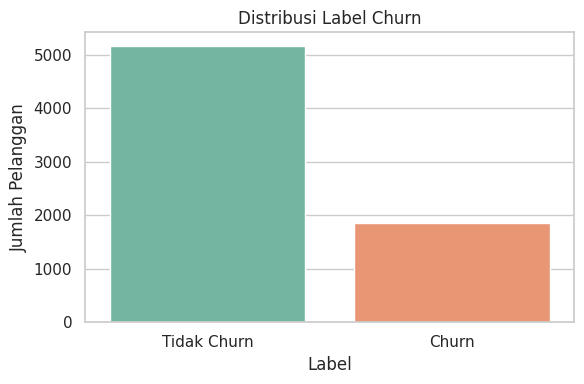

In [41]:
plt.figure(figsize=(6, 4))
sns.countplot(x=y.map({0: "Tidak Churn", 1: "Churn"}), hue=y.map({0: "Tidak Churn", 1: "Churn"}), palette="Set2", legend=False)
plt.title("Distribusi Label Churn")
plt.xlabel("Label")
plt.ylabel("Jumlah Pelanggan")
plt.tight_layout()
plt.show()

**Interpretasi Output:**  
Statistik label menunjukkan distribusi pelanggan churn dan tidak churn. Jika kelas tidak seimbang, maka model perlu dievaluasi menggunakan precision, recall, dan F1-score.

**Kesimpulan:**  
Label berhasil dibentuk dan distribusinya terdokumentasi untuk mendukung strategi evaluasi model.

---

### 2.2 Evaluasi Proses Pelabelan Diuraikan pada Laporan (deskriptif)

Evaluasi proses pelabelan:

| Aspek Evaluasi | Hasil |
|---|---|
| Sumber label | Kolom `Churn` dari dataset asli. |
| Tipe masalah | Klasifikasi biner. |
| Nilai valid | `Yes` dan `No`. |
| Mapping label | `Yes` = 1, `No` = 0. |
| Risiko | Distribusi label tidak sepenuhnya seimbang. |
| Tindak lanjut | Gunakan stratified split dan metrik evaluasi lengkap. |

**Kesimpulan Unit #7:**  
Pelabelan data berhasil dilakukan dan menghasilkan target numerik `Churn_Label` yang siap digunakan dalam pembangunan model Random Forest.

<a id="unit8"></a>

# UNIT #8 - Membangun Model
### Kode Unit: J.62DMI00.013.1

[Kembali ke Daftar Isi](#daftar-isi)

---

## 1. Menyiapkan Parameter Model

### 1.1 Parameter-parameter yang Sesuai dengan Model Diidentifikasi (deskriptif + kode)

Model utama yang digunakan adalah **Random Forest Classifier**. Random Forest dipilih karena cocok untuk data tabular, mampu menangani banyak fitur hasil encoding, dan dapat memberikan feature importance.

Parameter penting Random Forest:

| Parameter | Fungsi |
|---|---|
| `n_estimators` | Jumlah decision tree dalam forest. |
| `max_depth` | Kedalaman maksimum setiap tree. |
| `min_samples_split` | Jumlah minimum sampel untuk memecah node. |
| `min_samples_leaf` | Jumlah minimum sampel pada leaf node. |
| `max_features` | Jumlah fitur yang dipertimbangkan pada setiap split. |
| `class_weight` | Bobot kelas untuk membantu data tidak seimbang. |
| `random_state` | Menjaga hasil eksperimen tetap reproducible. |

**Catatan Pembelajaran:**  
Cell ini mengimpor tools Scikit-Learn untuk preprocessing, model Random Forest, split data, tuning parameter, dan evaluasi. Semua komponen pemodelan utama disiapkan di sini.

In [42]:
from sklearn.compose import ColumnTransformer
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (
    accuracy_score,
    classification_report,
    confusion_matrix,
    f1_score,
    precision_score,
    recall_score
)
from sklearn.model_selection import RandomizedSearchCV, train_test_split
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder

try:
    onehot_encoder = OneHotEncoder(handle_unknown="ignore", sparse_output=False)
except TypeError:
    onehot_encoder = OneHotEncoder(handle_unknown="ignore", sparse=False)

parameter_candidates = {
    "model__n_estimators": [200, 300, 500],
    "model__max_depth": [None, 10, 20, 30],
    "model__min_samples_split": [2, 5, 10],
    "model__min_samples_leaf": [1, 2, 4],
    "model__max_features": ["sqrt", "log2"]
}

parameter_candidates

{'model__n_estimators': [200, 300, 500],
 'model__max_depth': [None, 10, 20, 30],
 'model__min_samples_split': [2, 5, 10],
 'model__min_samples_leaf': [1, 2, 4],
 'model__max_features': ['sqrt', 'log2']}

**Interpretasi Output:**  
Output menampilkan kandidat parameter yang akan digunakan untuk optimasi Random Forest.

**Kesimpulan:**  
Parameter model telah diidentifikasi dan siap digunakan dalam proses tuning.

---

### 1.2 Nilai Toleransi Parameter Evaluasi Pengujian Ditetapkan Sesuai dengan Tujuan Teknis (deskriptif + kode)

Nilai toleransi evaluasi ditentukan berdasarkan tujuan teknis dan bisnis. Karena churn adalah kasus yang sensitif terhadap pelanggan yang benar-benar churn, recall dan F1-score untuk kelas churn perlu diperhatikan selain accuracy.

**Catatan Pembelajaran:**  
Cell ini menetapkan kriteria sukses model. Karena churn penting secara bisnis, metrik precision, recall, dan F1-score ikut digunakan selain accuracy.

In [43]:
success_criteria = pd.DataFrame({
    "Metrik": ["Accuracy", "Precision Churn", "Recall Churn", "F1-score Churn"],
    "Nilai Minimum": [0.75, 0.55, 0.55, 0.55],
    "Alasan": [
        "Model harus memiliki akurasi umum yang layak",
        "Prediksi churn perlu cukup tepat agar program retensi efisien",
        "Pelanggan churn perlu banyak terdeteksi",
        "Keseimbangan antara precision dan recall"
    ]
})

success_criteria

,Metrik,Nilai Minimum,Alasan
0,Accuracy,0.75,Model harus memiliki akurasi umum yang layak
1,Precision Churn,0.55,Prediksi churn perlu cukup tepat agar program ...
2,Recall Churn,0.55,Pelanggan churn perlu banyak terdeteksi
3,F1-score Churn,0.55,Keseimbangan antara precision dan recall


**Interpretasi Output:**  
Tabel menunjukkan batas minimum yang digunakan untuk menilai apakah model sudah cukup baik secara teknis.

**Kesimpulan:**  
Evaluasi model akan mempertimbangkan accuracy, precision, recall, dan F1-score, dengan perhatian khusus pada kelas churn.

---

## 2. Menggunakan Tools Pemodelan

### 2.1 Tools untuk Membuat Model Diidentifikasi Sesuai dengan Tujuan Teknis Data Science (deskriptif)

Tools yang digunakan:

| Tools | Fungsi |
|---|---|
| Pandas | Mengelola data tabular. |
| NumPy | Operasi numerik. |
| Scikit-Learn | Preprocessing, split data, training model, tuning, dan evaluasi. |
| Matplotlib/Seaborn | Visualisasi evaluasi dan feature importance. |

**Kesimpulan:**  
Scikit-Learn dipilih karena menyediakan workflow machine learning lengkap dan mendukung Random Forest Classifier.

---

### 2.2 Algoritma untuk Teknik Pemodelan yang Ditentukan Dibangun Menggunakan Tools yang Dipilih (kode)

Pipeline model dibangun dengan preprocessing dan Random Forest. Fitur kategorikal akan diubah menggunakan One-Hot Encoding, sedangkan fitur numerik diteruskan apa adanya.

**Catatan Pembelajaran:**  
Cell ini membangun pipeline model. Fitur numerik diteruskan apa adanya, fitur kategorikal diencoding dengan One-Hot Encoding, lalu model Random Forest dilatih.

In [44]:
numeric_features_model = X.select_dtypes(include=["number"]).columns.tolist()
categorical_features_model = [column for column in X.columns if column not in numeric_features_model]

preprocessor = ColumnTransformer(
    transformers=[
        ("num", "passthrough", numeric_features_model),
        ("cat", onehot_encoder, categorical_features_model)
    ]
)

random_forest = RandomForestClassifier(
    random_state=42,
    class_weight="balanced",
    n_jobs=-1
)

model_pipeline = Pipeline(steps=[
    ("preprocessor", preprocessor),
    ("model", random_forest)
])

print("Jumlah fitur numerik:", len(numeric_features_model))
print("Jumlah fitur kategorikal:", len(categorical_features_model))
print("Pipeline model berhasil dibuat.")

Jumlah fitur numerik: 11
Jumlah fitur kategorikal: 17
Pipeline model berhasil dibuat.


**Interpretasi Output:**  
Output menunjukkan jumlah fitur numerik dan kategorikal yang akan masuk ke pipeline. Pipeline memastikan preprocessing hanya dipelajari dari data latih sehingga mengurangi risiko data leakage.

**Kesimpulan:**  
Algoritma Random Forest telah dibangun dalam bentuk pipeline yang siap dieksekusi.

---

### 2.3 Algoritma Pemodelan Dieksekusi Sesuai dengan Skenario Pengujian dan Tools untuk Membuat Model yang Telah Ditetapkan (kode)

Skenario pengujian menggunakan train-test split dengan stratifikasi target agar proporsi churn dan tidak churn tetap seimbang pada data latih dan data uji.

**Catatan Pembelajaran:**  
Cell ini membagi data menjadi data latih dan data uji. `stratify=y` digunakan agar proporsi churn dan tidak churn tetap mirip pada train dan test.

In [45]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

print("Ukuran X_train:", X_train.shape)
print("Ukuran X_test:", X_test.shape)
print("Distribusi y_train:")
print(y_train.value_counts(normalize=True).round(3))
print("Distribusi y_test:")
print(y_test.value_counts(normalize=True).round(3))

Ukuran X_train: (5616, 28)
Ukuran X_test: (1405, 28)
Distribusi y_train:
Churn_Label
0    0.736
1    0.264
Name: proportion, dtype: float64
Distribusi y_test:
Churn_Label
0    0.735
1    0.265
Name: proportion, dtype: float64


**Catatan Pembelajaran:**  
Cell ini melatih model baseline Random Forest dan menghitung metrik awal. Hasil baseline menjadi pembanding sebelum tuning parameter.

In [46]:
baseline_model = model_pipeline
baseline_model.fit(X_train, y_train)

baseline_predictions = baseline_model.predict(X_test)

baseline_metrics = pd.DataFrame({
    "Metrik": ["Accuracy", "Precision Churn", "Recall Churn", "F1-score Churn"],
    "Nilai": [
        accuracy_score(y_test, baseline_predictions),
        precision_score(y_test, baseline_predictions),
        recall_score(y_test, baseline_predictions),
        f1_score(y_test, baseline_predictions)
    ]
})

baseline_metrics["Nilai"] = baseline_metrics["Nilai"].round(4)
baseline_metrics

,Metrik,Nilai
0,Accuracy,0.7616
1,Precision Churn,0.5466
2,Recall Churn,0.5833
3,F1-score Churn,0.5644


**Interpretasi Output:**  
Output pertama menunjukkan pembagian data latih dan data uji. Output kedua menunjukkan performa awal Random Forest sebelum optimasi parameter.

**Kesimpulan:**  
Model baseline berhasil dilatih dan menghasilkan metrik awal untuk dibandingkan dengan model hasil optimasi.

---

### 2.4 Parameter Model Algoritma Dioptimasi untuk Menghasilkan Nilai Parameter Evaluasi yang Sesuai dengan Skenario Pengujian (kode)

Optimasi parameter dilakukan menggunakan `RandomizedSearchCV` dengan metrik utama `f1`, karena F1-score mempertimbangkan precision dan recall pada kasus churn.

**Catatan Pembelajaran:**  
Cell ini melakukan optimasi parameter dengan RandomizedSearchCV. Tujuannya mencari kombinasi parameter yang memberi F1-score terbaik pada validasi silang.

In [47]:
random_search = RandomizedSearchCV(
    estimator=model_pipeline,
    param_distributions=parameter_candidates,
    n_iter=12,
    scoring="f1",
    cv=3,
    random_state=42,
    n_jobs=-1,
    verbose=1
)

random_search.fit(X_train, y_train)

best_model = random_search.best_estimator_

print("Best F1 CV Score:", round(random_search.best_score_, 4))
print("Best Parameters:")
print(random_search.best_params_)

Fitting 3 folds for each of 12 candidates, totalling 36 fits
Best F1 CV Score: 0.6301
Best Parameters:
{'model__n_estimators': 200, 'model__min_samples_split': 10, 'model__min_samples_leaf': 4, 'model__max_features': 'log2', 'model__max_depth': 30}


**Catatan Pembelajaran:**  
Cell ini membandingkan performa baseline dan model hasil tuning. Dari sini bisa dilihat apakah optimasi parameter meningkatkan hasil model.

In [48]:
optimized_predictions = best_model.predict(X_test)

optimized_metrics = pd.DataFrame({
    "Metrik": ["Accuracy", "Precision Churn", "Recall Churn", "F1-score Churn"],
    "Nilai Baseline": [
        accuracy_score(y_test, baseline_predictions),
        precision_score(y_test, baseline_predictions),
        recall_score(y_test, baseline_predictions),
        f1_score(y_test, baseline_predictions)
    ],
    "Nilai Optimized": [
        accuracy_score(y_test, optimized_predictions),
        precision_score(y_test, optimized_predictions),
        recall_score(y_test, optimized_predictions),
        f1_score(y_test, optimized_predictions)
    ]
})

optimized_metrics[["Nilai Baseline", "Nilai Optimized"]] = optimized_metrics[["Nilai Baseline", "Nilai Optimized"]].round(4)
optimized_metrics

,Metrik,Nilai Baseline,Nilai Optimized
0,Accuracy,0.7616,0.7665
1,Precision Churn,0.5466,0.5431
2,Recall Churn,0.5833,0.7446
3,F1-score Churn,0.5644,0.6281


**Interpretasi Output:**  
Output menampilkan parameter terbaik dan perbandingan performa model baseline dengan model hasil optimasi.

**Kesimpulan Unit #8:**  
Model Random Forest berhasil dibangun, dilatih, dan dioptimasi. Model terbaik disimpan sebagai `best_model` untuk dievaluasi lebih lanjut pada Unit #9.

<a id="unit9"></a>

# UNIT #9 - Mengevaluasi Hasil Pemodelan
### Kode Unit: J.62DMI00.014.1

[Kembali ke Daftar Isi](#daftar-isi)

---

## 1. Menggunakan Model dengan Data Riil

### 1.1 Data Baru untuk Evaluasi Pemodelan Dikumpulkan Sesuai Kebutuhan yang Mengacu kepada Parameter Evaluasi (deskriptif + kode)

Dalam project ini, data riil untuk evaluasi direpresentasikan oleh data uji (`X_test`) yang dipisahkan dari dataset sebelum training. Data ini tidak digunakan saat model belajar, sehingga dapat menjadi simulasi data pelanggan baru yang belum pernah dilihat model.

**Catatan Pembelajaran:**  
Cell ini mendokumentasikan data uji sebagai simulasi data riil. Data uji tidak digunakan saat training, sehingga cocok untuk menilai kemampuan generalisasi model.

In [49]:
evaluation_data_summary = pd.DataFrame({
    "Komponen": ["Data evaluasi", "Jumlah record", "Jumlah fitur", "Sumber", "Status terhadap training"],
    "Keterangan": [
        "X_test dan y_test",
        X_test.shape[0],
        X_test.shape[1],
        "Hold-out dari dataset Telco Customer Churn",
        "Tidak digunakan saat training"
    ]
})

evaluation_data_summary

,Komponen,Keterangan
0,Data evaluasi,X_test dan y_test
1,Jumlah record,1405
2,Jumlah fitur,28
3,Sumber,Hold-out dari dataset Telco Customer Churn
4,Status terhadap training,Tidak digunakan saat training


**Interpretasi Output:**  
Tabel menunjukkan data yang digunakan untuk evaluasi model. Data uji digunakan sebagai pendekatan data riil karena model belum pernah mempelajari data tersebut saat training.

**Kesimpulan:**  
Data evaluasi telah disiapkan sesuai kebutuhan parameter evaluasi model.

---

### 1.2 Model Diuji dengan Menggunakan Data Riil yang Telah Dikumpulkan (kode)

Model terbaik diuji menggunakan `X_test`. Selain prediksi kelas, model juga menghasilkan probabilitas churn.

**Catatan Pembelajaran:**  
Cell ini menggunakan model terbaik untuk memprediksi data uji. Selain kelas prediksi, model juga menghasilkan probabilitas churn untuk membaca tingkat risiko pelanggan.

In [50]:
y_pred = best_model.predict(X_test)
y_pred_proba = best_model.predict_proba(X_test)[:, 1]

prediction_result = X_test.copy()
prediction_result["Actual_Churn"] = y_test.values
prediction_result["Predicted_Churn"] = y_pred
prediction_result["Churn_Probability"] = y_pred_proba

prediction_result[["Actual_Churn", "Predicted_Churn", "Churn_Probability"]].head(10)

,Actual_Churn,Predicted_Churn,Churn_Probability
5627,0,1,0.825057
6126,1,1,0.661941
2361,1,1,0.727744
2201,0,0,0.195304
832,0,0,0.200534
683,0,0,0.428483
3403,0,0,0.220997
6240,1,1,0.914468
3996,0,0,0.016880
4285,0,0,0.124705


**Interpretasi Output:**  
Output menampilkan hasil prediksi model pada data uji. Kolom `Churn_Probability` menunjukkan estimasi peluang pelanggan untuk churn.

**Kesimpulan:**  
Model berhasil digunakan untuk memprediksi churn pada data evaluasi.

---

## 2. Menilai Hasil Pemodelan

### 2.1 Keluaran Pengujian Model Dinilai Berdasarkan Metrik Kesuksesan (kode)

Evaluasi dilakukan menggunakan confusion matrix, classification report, accuracy, precision, recall, dan F1-score.

**Catatan Pembelajaran:**  
Cell ini membuat confusion matrix. Matriks ini menunjukkan jumlah prediksi benar dan salah untuk kelas churn dan tidak churn.

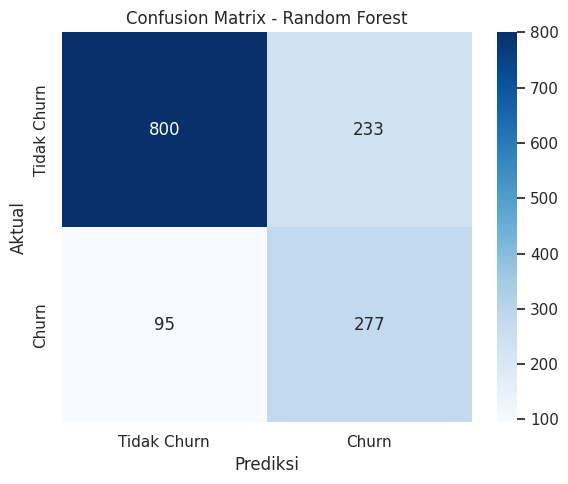

In [51]:
cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(6, 5))
sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=["Tidak Churn", "Churn"],
    yticklabels=["Tidak Churn", "Churn"]
)
plt.title("Confusion Matrix - Random Forest")
plt.xlabel("Prediksi")
plt.ylabel("Aktual")
plt.tight_layout()
plt.show()

**Catatan Pembelajaran:**  
Cell ini menampilkan precision, recall, dan F1-score untuk setiap kelas. Untuk kasus churn, recall kelas churn penting karena perusahaan ingin mendeteksi pelanggan yang berisiko pergi.

In [52]:
print(classification_report(y_test, y_pred, target_names=["Tidak Churn", "Churn"]))

              precision    recall  f1-score   support

 Tidak Churn       0.89      0.77      0.83      1033
       Churn       0.54      0.74      0.63       372

    accuracy                           0.77      1405
   macro avg       0.72      0.76      0.73      1405
weighted avg       0.80      0.77      0.78      1405



**Catatan Pembelajaran:**  
Cell ini merangkum metrik akhir dan membandingkannya dengan target minimum. Kolom status menunjukkan apakah hasil model sudah memenuhi kriteria sukses.

In [53]:
final_metrics = pd.DataFrame({
    "Metrik": ["Accuracy", "Precision Churn", "Recall Churn", "F1-score Churn"],
    "Nilai": [
        accuracy_score(y_test, y_pred),
        precision_score(y_test, y_pred),
        recall_score(y_test, y_pred),
        f1_score(y_test, y_pred)
    ],
    "Minimum Target": [0.75, 0.55, 0.55, 0.55]
})

final_metrics["Status"] = np.where(final_metrics["Nilai"] >= final_metrics["Minimum Target"], "Memenuhi", "Belum Memenuhi")
final_metrics["Nilai"] = final_metrics["Nilai"].round(4)
final_metrics

,Metrik,Nilai,Minimum Target,Status
0,Accuracy,0.7665,0.75,Memenuhi
1,Precision Churn,0.5431,0.55,Belum Memenuhi
2,Recall Churn,0.7446,0.55,Memenuhi
3,F1-score Churn,0.6281,0.55,Memenuhi


**Interpretasi Output:**  
Confusion matrix menunjukkan jumlah prediksi benar dan salah. Classification report menunjukkan precision, recall, dan F1-score untuk masing-masing kelas. Tabel final metrics membandingkan hasil model dengan target minimum yang telah ditetapkan.

**Kesimpulan:**  
Keluaran model dapat dinilai secara teknis menggunakan metrik klasifikasi. Untuk kasus churn, recall dan F1-score kelas churn menjadi perhatian utama.

---

### Feature Importance Random Forest (kode + interpretasi bisnis)

Feature importance digunakan untuk menjawab pertanyaan bisnis: faktor apa yang paling memengaruhi churn menurut model.

**Catatan Pembelajaran:**  
Cell ini mengambil feature importance dari Random Forest. Hasilnya membantu menjawab faktor apa saja yang paling berpengaruh dalam prediksi churn menurut model.

In [54]:
fitted_preprocessor = best_model.named_steps["preprocessor"]
fitted_rf = best_model.named_steps["model"]

numeric_feature_names = numeric_features_model
categorical_feature_names = []

if categorical_features_model:
    fitted_encoder = fitted_preprocessor.named_transformers_["cat"]
    categorical_feature_names = fitted_encoder.get_feature_names_out(categorical_features_model).tolist()

all_feature_names = numeric_feature_names + categorical_feature_names

feature_importance = pd.DataFrame({
    "Feature": all_feature_names,
    "Importance": fitted_rf.feature_importances_
}).sort_values("Importance", ascending=False)

feature_importance.head(20)

,Feature,Importance
1,tenure,0.102524
3,TotalCharges,0.080666
43,Contract_Month-to-month,0.076358
4,avg_charges_per_tenure,0.059780
2,MonthlyCharges,0.056439
45,Contract_Two year,0.047945
34,TechSupport_No,0.047517
23,InternetService_Fiber optic,0.047093
52,tenure_group_0-12 bulan,0.034382
25,OnlineSecurity_No,0.032792


**Catatan Pembelajaran:**  
Cell ini memvisualisasikan 15 fitur terpenting. Grafik ini bisa dipakai untuk menjelaskan faktor churn secara lebih mudah saat presentasi.

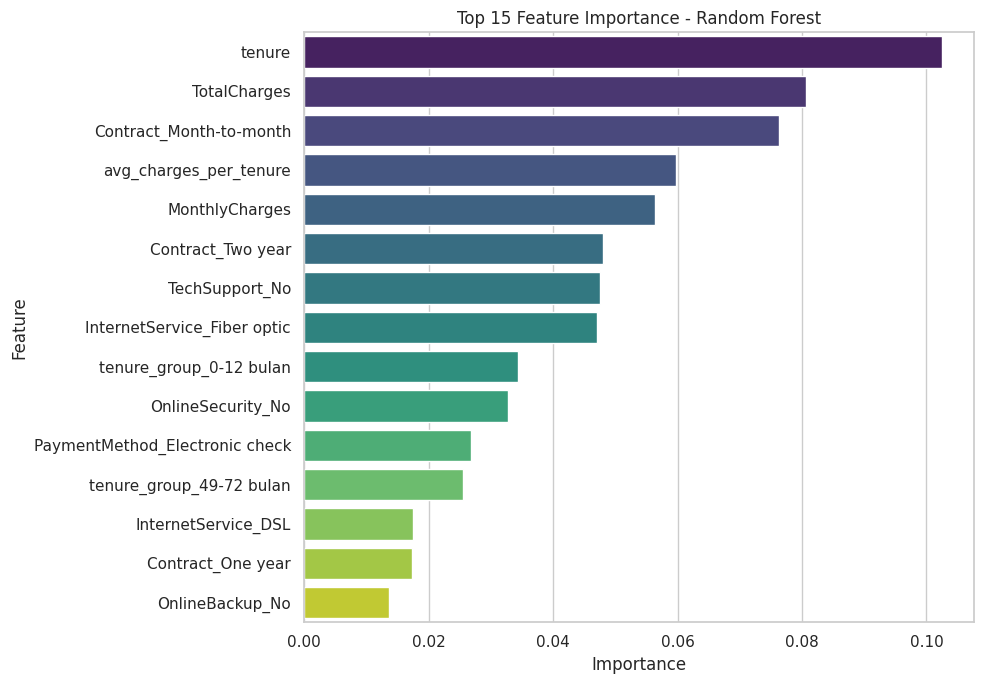

In [55]:
plt.figure(figsize=(10, 7))
sns.barplot(
    data=feature_importance.head(15),
    x="Importance",
    y="Feature",
    hue="Feature",
    palette="viridis",
    legend=False
)
plt.title("Top 15 Feature Importance - Random Forest")
plt.xlabel("Importance")
plt.ylabel("Feature")
plt.tight_layout()
plt.show()

**Interpretasi Output:**  
Feature importance menunjukkan fitur yang paling banyak digunakan model untuk membuat keputusan prediksi. Fitur dengan importance tinggi dapat dianggap sebagai faktor yang paling berkontribusi terhadap prediksi churn.

**Kesimpulan:**  
Hasil feature importance dapat digunakan untuk menyusun rekomendasi bisnis, misalnya fokus pada pelanggan dengan kontrak bulanan, tenure rendah, biaya tinggi, atau layanan pendukung yang tidak aktif.

---

### 2.2 Hasil Penilaian Didokumentasikan Sesuai Standar yang Berlaku (deskriptif)

Dokumentasi hasil evaluasi:

| Aspek | Dokumentasi |
|---|---|
| Model | Random Forest Classifier. |
| Preprocessing | One-Hot Encoding untuk fitur kategorikal, passthrough untuk fitur numerik. |
| Split data | Train-test split 80:20 dengan stratifikasi target. |
| Optimasi | RandomizedSearchCV dengan scoring `f1`. |
| Metrik evaluasi | Accuracy, precision, recall, F1-score, confusion matrix, classification report. |
| Interpretasi model | Feature importance. |

Rekomendasi bisnis:

1. Prioritaskan pelanggan dengan probabilitas churn tinggi untuk program retensi.
2. Berikan perhatian khusus pada pelanggan kontrak bulanan dan tenure rendah.
3. Evaluasi paket layanan dengan biaya bulanan tinggi agar tetap kompetitif.
4. Dorong penggunaan layanan pendukung seperti `TechSupport` dan `OnlineSecurity`.
5. Tawarkan insentif kontrak jangka panjang atau metode pembayaran otomatis.
6. Gunakan probabilitas churn sebagai dasar segmentasi risiko pelanggan.

**Kesimpulan Unit #9:**  
Model Random Forest telah dievaluasi menggunakan data uji yang tidak digunakan saat training. Hasil evaluasi didokumentasikan melalui metrik klasifikasi, confusion matrix, classification report, dan feature importance. Model dapat digunakan sebagai dasar sistem pendukung keputusan untuk strategi retensi pelanggan.

---

# Kesimpulan Akhir Project

Project **Customer Churn Classification** berhasil membangun alur data science dari pengumpulan data hingga evaluasi model. Dataset IBM Telco Customer Churn digunakan untuk memprediksi pelanggan yang berisiko churn berdasarkan karakteristik pelanggan, layanan, kontrak, dan pembayaran.

Tahapan utama yang telah dilakukan:

1. Data dikumpulkan dari Kaggle dan dibaca sebagai CSV lokal.
2. Data ditelaah melalui tipe data, statistik, relasi, dan visualisasi.
3. Data divalidasi dari sisi kualitas dan kecukupan.
4. Objek data ditentukan dengan menghapus kolom identitas `customerID` dari fitur.
5. Data dibersihkan, terutama pada kolom `TotalCharges`.
6. Fitur baru dibuat berdasarkan konteks bisnis churn.
7. Label `Churn` dikonversi menjadi label biner.
8. Model Random Forest dibangun dan dioptimasi.
9. Model dievaluasi menggunakan metrik klasifikasi dan feature importance.

Secara bisnis, model ini dapat membantu perusahaan mengidentifikasi pelanggan berisiko churn lebih awal sehingga tindakan retensi dapat dilakukan secara lebih tepat sasaran.